In [2]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib
import numpy as np, re, torch
from torch import nn
from torch.utils.data import Dataset, DataLoader


In [3]:
import glob
import xarray as xr

PATH = "/Users/lb962/Documents/GitHub/ESL/data/ml_ready/*.nc"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]

File 0: /Users/lb962/Documents/GitHub/ESL/data/ml_ready/small_ds.nc
<xarray.Dataset>
Dimensions:            (station: 9, valid_time: 750192)
Coordinates:
  * station            (station) int64 1 2 3 4 5 6 7 8 10
  * valid_time         (valid_time) datetime64[ns] 1940-01-01 ... 2025-07-30T...
    latitude           float64 ...
    longitude          float64 ...
    station_latitude   (station) float64 ...
    station_longitude  (station) float64 ...
Data variables: (12/14)
    u10                (station, valid_time) float32 ...
    v10                (station, valid_time) float32 ...
    d2m                (station, valid_time) float32 ...
    t2m                (station, valid_time) float32 ...
    msl                (station, valid_time) float32 ...
    sst                (station, valid_time) float32 ...
    ...                 ...
    mwd                (station, valid_time) float32 ...
    mwp                (station, valid_time) float32 ...
    swh                (station, valid_

In [4]:
def preprocess(ds):
    return ds.sortby("station") 

datasets = [preprocess(xr.open_dataset(f)) for f in files]
ds = xr.concat(datasets, dim="station")
ds_sealevel = ds

In [5]:
ds_recent = ds.where(ds["valid_time"].dt.year >= 2000, drop=True)

In [6]:
ds = ds_recent

In [7]:
# Ensure time is sorted (important for derivatives)
ds = ds.sortby("valid_time")

# --- Core helpers (finite differences over hours) ---
def diff_hours(da, hours: int):
    """Finite-difference derivative over 'hours' (value change per hour)."""
    return (da - da.shift(valid_time=hours)) / hours

# --- Wind features ---
u = ds["u10"]
v = ds["v10"]
wind_speed = np.hypot(u, v).rename("wind_speed")

d_wind_1h = diff_hours(wind_speed, 1).rename("d_wind_1h")   # Δwind / 1h
d_wind_6h = diff_hours(wind_speed, 6).rename("d_wind_6h")   # Δwind / 6h

# --- Pressure derivatives (dsp/dt) ---
sp = ds["sp"]
d_sp_1h = diff_hours(sp, 1).rename("d_sp_1h")
d_sp_6h = diff_hours(sp, 6).rename("d_sp_6h")

# --- Tide shifted features ---
tide_lag1h = ds["tide"].shift(valid_time=1).rename("tide_lag1h")
tide_lag6h = ds["tide"].shift(valid_time=6).rename("tide_lag6h")
tide_lag0h = ds["tide"].shift(valid_time=0).rename("tide_lag0h")

# Make sure sorted
ds = ds.sortby("valid_time")

# Pull just tide to a tidy frame
df = ds[["tide"]].to_dataframe().reset_index()
df = df.sort_values(["station", "valid_time"])

# Compute tidal range per station (across all valid_time)
tide_range = (ds["tide"].max(dim="valid_time") - ds["tide"].min(dim="valid_time"))
tide_range = tide_range.rename("tide_range")

# --- Air density (rho_air) ---
# Use sp (Pa) and t2m (K) if available; else fallback to 1.225 kg/m^3
R_d = 287.05  # J kg^-1 K^-1
if "sp" in ds and "t2m" in ds:
    rho_air = (ds["sp"] / (R_d * ds["t2m"])).astype("float32").rename("rho_air")
else:
    rho_air = xr.zeros_like(wind_speed) + 1.225
    rho_air = rho_air.astype("float32").rename("rho_air")

# --- Drag coefficient C_D (Large & Pond style) ---
U = wind_speed
Cd = xr.where(
    U < 11.0,
    1.14e-3,
    xr.where(U <= 25.0, (0.49 + 0.065 * U) * 1e-3, 2.0e-3)
).astype("float32").rename("Cd")

# --- Wind stress components (N/m^2 = Pa) ---
tau_x = (rho_air * Cd * U * u).astype("float32").rename("tau_x")
tau_y = (rho_air * Cd * U * v).astype("float32").rename("tau_y")
tau_mag = (rho_air * Cd * U**2).astype("float32").rename("tau_mag")

# Optional: tendencies (change over 1h/6h), consistent with your diff_hours helper
tau_d1h = diff_hours(tau_mag, 1).astype("float32").rename("d_tau_1h")
tau_d6h = diff_hours(tau_mag, 6).astype("float32").rename("d_tau_6h")

# --- Assemble into one dataset ---
feat_ds = xr.Dataset(
    {
        "wind_speed": wind_speed,
        "d_wind_1h": d_wind_1h,
        "d_wind_6h": d_wind_6h,
        "d_sp_1h": d_sp_1h,
        "d_sp_6h": d_sp_6h,
        "tide_range_12h": tide_range,
        "tide_lag0h": tide_lag0h,
        "tide_lag1h": tide_lag1h,
        "tide_lag6h": tide_lag6h,
        # "d_msl_1h": d_msl_1h,  # uncomment if you computed these
        # "d_msl_6h": d_msl_6h,
        "tau_x": tau_x,
        "tau_y": tau_y,
        "tau_mag": tau_mag,
        "tau_d1h": tau_d1h,
        "tau_d6h": tau_d6h,
    }
)

# Keep original coordinates/attrs
feat_ds = feat_ds.assign_coords(
    station=ds["station"],
    valid_time=ds["valid_time"]
)
for v in feat_ds.data_vars:
    feat_ds[v].attrs.update(ds[v.split("_")[0]].attrs if v.split("_")[0] in ds.data_vars else {})

# Merge features back with original dataset (optional)
ds_engineered = xr.merge([ds, feat_ds])

In [8]:
ds_engineered = ds_engineered.where(ds["valid_time"].dt.year >= 2000, drop=True)

In [9]:
# exclude target + sea_level + tide from predictors
predictors = [v for v in ds_engineered.data_vars if v not in ["residual", "sea_level", "tide", "longitude", "latitude", "station_longitude", "station_latitude", "station", "valid_time"]]
target = "residual"
features_df = ds_engineered[predictors + [target]].to_dataframe().reset_index()
features_df = features_df.dropna(subset=[target])

# ADd bathymetry_stats

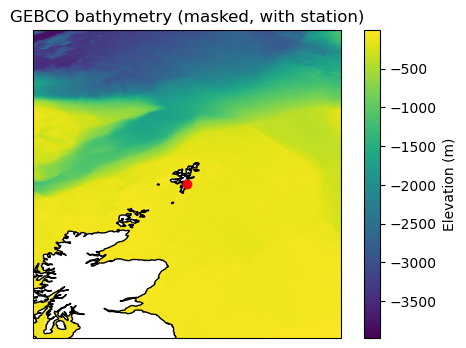

In [10]:
# Open the GEBCO NetCDF file
file_path = "/Users/lb962/Documents/Phd/AExtremesEOF/data/GEBCO/gebco_2024_n70.0_s47.0_w-20.0_e15.0.nc"
GEBCO_ds = xr.open_dataset(file_path)

# extract station ids and their lat/lon
stations = ds_sealevel['station'].values
lats = ds_sealevel['station_latitude'].values
lons = ds_sealevel['station_longitude'].values
station = ds_sealevel['station'].values

# build mapping from (lat, lon) to station index
latlon_to_station = {
    (float(lat), float(lon)): int(stn)
    for stn, lat, lon in zip(stations, lats, lons)
}

# if you want unique lat/lon pairs:
unique_latlon = list(latlon_to_station.keys())

# Function to extract square around a lat/lon
def extract_square(ds, lat, lon, size_deg):
    half = size_deg / 2
    return ds.sel(
        lat=slice(lat + half, lat - half),  # GEBCO lat usually descending
        lon=slice(lon - half, lon + half),
        method="nearest"
    )

results = {
    "0.1x0.1": [],
    "0.25x0.25": [],
    "1x1": [],
    "3x3": [],
    "10x10":[]
}
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

def mask_land_gt1m(ds_tile):
    """Mask elevations shallower than -0.5 m (land/coast) as NaN."""
    return ds_tile.assign(elevation=ds_tile["elevation"].where(ds_tile["elevation"] <= -0.5))

def plot_tile(ds_tile, title="GEBCO bathymetry (masked, with station)"):
    """Plot a masked GEBCO tile with Cartopy and a red station dot at the center."""
    masked = mask_land_gt1m(ds_tile)

    # Compute the center coordinate (station location)
    center_lat = float(masked.lat.mean())
    center_lon = float(masked.lon.mean())
    
    fig = plt.figure(figsize=(6, 4))
    ax = plt.axes(projection=ccrs.PlateCarree())

    # Bathymetry raster
    pcm = ax.pcolormesh(
        masked["lon"], masked["lat"], masked["elevation"],
        transform=ccrs.PlateCarree()
    )

    # Coastlines and extent
    ax.coastlines(resolution="10m")
    ax.set_title(title)
    ax.set_extent([
        float(masked.lon.min()), float(masked.lon.max()),
        float(masked.lat.min()), float(masked.lat.max())
    ], crs=ccrs.PlateCarree())

    # Station red dot
    ax.plot(center_lon, center_lat, 'ro', markersize=6, transform=ccrs.PlateCarree())

    # Colorbar
    plt.colorbar(pcm, ax=ax, label="Elevation (m)")
    plt.show()

def extract_square(ds, lat, lon, size_deg):
    """Fast spatial slice using coordinate indices."""
    half = size_deg / 2
    return ds.sel(
        lat=slice(lat - half, lat + half),
        lon=slice(lon - half, lon + half)
    )

# --- Prep: ensure coordinates are monotonic so .sel(slice) is efficient ---
GEBCO_ds = GEBCO_ds.sortby(["lat", "lon"])

# Available resolutions (keep all for each point)
resolutions = [0.1, 0.25, 1.0, 3.0, 10.0]

# Initialize results dict
results = {f"{r}x{r}": [] for r in resolutions}
#results = {r: [] for r in resolutions}

# Build tiles for every (lat, lon) at every resolution
for lat, lon in unique_latlon:
    for size in resolutions:
        key = f"{size}x{size}"
        results[key].append(extract_square(GEBCO_ds, lat, lon, size))

plot_tile(results["10.0x10.0"][0])

In [11]:
import numpy as np, re, torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# --- simple helpers reused from earlier ---
def _label_from_key(k):
    s = str(k)
    m = re.match(r'^\s*([0-9]*\.?[0-9]+)\s*x', s)  # "0.25x0.25" -> "0.25"
    if m: return f"{float(m.group(1)):g}"
    try:   return f"{float(s):g}"                  # "1.0" -> "1"
    except: return s.strip()

def to_128x128(ds_tile, var='elevation'):
    v = ds_tile[var].sortby(['lat','lon'])
    lat_new = np.linspace(float(v['lat'].min()), float(v['lat'].max()), 128)
    lon_new = np.linspace(float(v['lon'].min()), float(v['lon'].max()), 128)
    v128 = v.interp(lat=lat_new, lon=lon_new)
    arr = v128.values.astype(np.float32)
    return arr

def prep_image(arr):
    # fill NaNs (masked land) and standardize per-tile (mean/std) for stable training
    arr = np.nan_to_num(arr, nan=0.0)
    m, s = float(arr.mean()), float(arr.std() + 1e-6)
    arr = (arr - m) / s
    return arr[None, ...]  # (1, 128, 128)
def collect_tiles_for_resolution(results_by_station, res_label, var='elevation', stations_subset=None):
    """Return list of (station_str, np.ndarray[1,128,128]) for a given resolution label."""
    items = []
    for stn, tiles in results_by_station.items():
        if stations_subset is not None and stn not in stations_subset:
            continue
        if res_label in tiles:
            arr = to_128x128(tiles[res_label], var=var)
            items.append((str(stn), prep_image(arr)))
    return items


In [12]:
class TinyPatchMAE(nn.Module):
    """
    Minimal MAE:
      - Patchify 128x128 into (P x P) patches (default P=16 -> 64 patches).
      - Encoder: tiny Transformer (2 layers).
      - Decoder: tiny Transformer (1 layer) to reconstruct masked patches.
      - Embedding: mean of encoder tokens (no [CLS]) -> fixed-length vector.
    """
    def __init__(self, patch_size=16, embed_dim=128, encoder_layers=2, decoder_layers=1, nhead=4, mlp_ratio=2.0, mask_ratio=0.6):
        super().__init__()
        assert 128 % patch_size == 0
        self.patch = patch_size
        self.num_patches = (128 // patch_size) ** 2
        self.patch_dim = patch_size * patch_size  # grayscale
        self.mask_ratio = mask_ratio

        # patch embed
        self.proj = nn.Linear(self.patch_dim, embed_dim)

        # learnable 2D pos embedding (N, D)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim))

        # encoder
        enc_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead, dim_feedforward=int(embed_dim*mlp_ratio), batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=encoder_layers)

        # decoder: uses mask tokens + pos
        self.mask_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        dec_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead, dim_feedforward=int(embed_dim*mlp_ratio), batch_first=True)
        self.decoder = nn.TransformerEncoder(dec_layer, num_layers=decoder_layers)
        self.pred = nn.Linear(embed_dim, self.patch_dim)  # predict pixels per patch

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.mask_token, std=0.02)

    # ---- utilities ----
    def _patchify(self, x):
        # x: (B,1,128,128) -> patches (B, N, P*P)
        B, _, H, W = x.shape
        p = self.patch
        x = x.unfold(2, p, p).unfold(3, p, p)  # (B,1,H/p,W/p,p,p)
        x = x.contiguous().view(B, 1, (H//p)*(W//p), p, p)
        x = x.squeeze(1).flatten(2)            # (B, N, P*P)
        return x

    def _unpatchify(self, patches):
        # patches: (B, N, P*P) -> (B,1,128,128)
        B, N, D = patches.shape
        p = self.patch
        G = int((N) ** 0.5)
        x = patches.view(B, G, G, p, p).permute(0,3,1,4,2)  # (B,p,G,p,G)
        x = x.reshape(B, 1, G*p, G*p)
        return x

    def _random_mask(self, N, B, device):
        # returns: ids_keep, ids_mask, ids_restore per sample
        ids = torch.argsort(torch.rand(B, N, device=device), dim=1)
        num_keep = int((1.0 - self.mask_ratio) * N)
        ids_keep = ids[:, :num_keep]
        ids_mask = ids[:, num_keep:]
        # restore index positions
        ids_restore = torch.argsort(ids, dim=1)
        return ids_keep, ids_mask, ids_restore

    # ---- forward passes ----
    def forward(self, imgs):
        # imgs: (B,1,128,128)
        patches = self._patchify(imgs)                # (B,N,P^2)
        tokens = self.proj(patches)                   # (B,N,D)
        B, N, D = tokens.shape
        pos = self.pos_embed.expand(B, -1, -1)        # (B,N,D)

        ids_keep, ids_mask, ids_restore = self._random_mask(N, B, tokens.device)

        # gather visible tokens + pos
        x_vis = torch.gather(tokens, 1, ids_keep.unsqueeze(-1).expand(-1,-1,D))
        pos_vis = torch.gather(pos,    1, ids_keep.unsqueeze(-1).expand(-1,-1,D))
        x_vis = x_vis + pos_vis

        # encoder
        z = self.encoder(x_vis)                       # (B, N_vis, D)

        # decoder input: put encoded tokens back with mask tokens, then add pos
        B, N_vis, D = z.shape
        N_mask = N - N_vis
        mask_tokens = self.mask_token.expand(B, N_mask, D)
        x_full = torch.zeros(B, N, D, device=imgs.device)
        x_full.scatter_(1, ids_keep.unsqueeze(-1).expand(-1,-1,D), z)
        x_full.scatter_(1, ids_mask.unsqueeze(-1).expand(-1,-1,D), mask_tokens)
        x_full = x_full + pos

        y = self.decoder(x_full)                      # (B,N,D)
        pred = self.pred(y)                           # (B,N,P^2)

        # loss on masked patches only
        target = patches
        loss = ((pred.gather(1, ids_mask.unsqueeze(-1).expand(-1,-1,self.patch_dim)) -
                 target.gather(1, ids_mask.unsqueeze(-1).expand(-1,-1,self.patch_dim))) ** 2).mean()
        return loss, pred, ids_mask

    @torch.no_grad()
    def embed(self, imgs):
        """Return mean-pooled encoder tokens as the embedding (B, D)."""
        patches = self._patchify(imgs)
        tokens = self.proj(patches)
        B, N, D = tokens.shape
        pos = self.pos_embed.expand(B, -1, -1)
        # no masking for embedding
        x = tokens + pos
        z = self.encoder(x)
        return z.mean(dim=1)  # (B, D)

In [13]:
class TileDataset(Dataset):
    def __init__(self, items):  # items: list[(station_str, np.ndarray[1,128,128])]
        self.items = items
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        sid, arr = self.items[i]
        x = torch.from_numpy(arr.astype(np.float32))  # (1,128,128)
        return x, sid

def train_mae_on_tiles(tiles, *, epochs=8, batch_size=32, lr=1e-3, weight_decay=1e-5,
                       patch_size=16, embed_dim=128, mask_ratio=0.6, device='cpu', verbose=True):
    ds = TileDataset(tiles)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=0)
    mae = TinyPatchMAE(patch_size=patch_size, embed_dim=embed_dim, mask_ratio=mask_ratio).to(device)
    opt = torch.optim.AdamW(mae.parameters(), lr=lr, weight_decay=weight_decay)

    for ep in range(1, epochs+1):
        mae.train(); loss_sum=0.0; n=0
        for xb, _ in dl:
            xb = xb.to(device)
            opt.zero_grad(set_to_none=True)
            loss, _, _ = mae(xb)
            loss.backward(); opt.step()
            loss_sum += float(loss) * xb.size(0); n += xb.size(0)
        if verbose:
            print(f"MAE epoch {ep:02d}/{epochs} - loss {loss_sum/max(1,n):.4f}")
    return mae


In [14]:
class TileDataset(Dataset):
    def __init__(self, items):  # items: list[(station_str, np.ndarray[1,128,128])]
        self.items = items
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        sid, arr = self.items[i]
        x = torch.from_numpy(arr.astype(np.float32))  # (1,128,128)
        return x, sid

def train_mae_on_tiles(tiles, *, epochs=8, batch_size=32, lr=1e-3, weight_decay=1e-5,
                       patch_size=16, embed_dim=128, mask_ratio=0.6, device='cpu', verbose=True):
    ds = TileDataset(tiles)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=True, num_workers=0)
    mae = TinyPatchMAE(patch_size=patch_size, embed_dim=embed_dim, mask_ratio=mask_ratio).to(device)
    opt = torch.optim.AdamW(mae.parameters(), lr=lr, weight_decay=weight_decay)

    for ep in range(1, epochs+1):
        mae.train(); loss_sum=0.0; n=0
        for xb, _ in dl:
            xb = xb.to(device)
            opt.zero_grad(set_to_none=True)
            loss, _, _ = mae(xb)
            loss.backward(); opt.step()
            loss_sum += float(loss) * xb.size(0); n += xb.size(0)
        if verbose:
            print(f"MAE epoch {ep:02d}/{epochs} - loss {loss_sum/max(1,n):.4f}")
    return mae


In [15]:
@torch.no_grad()
def encode_tiles_with_mae(mae, tiles, device='cpu'):
    ds = TileDataset(tiles)
    dl = DataLoader(ds, batch_size=128, shuffle=False, num_workers=0)
    mae.eval(); embs = {}
    for xb, sids in dl:
        xb = xb.to(device)
        z = mae.embed(xb).cpu().numpy().astype(np.float32)  # (B, D)
        for sid, vec in zip(sids, z):
            embs[str(sid)] = vec
    return embs  # station_str -> vector

def merge_mae_embeddings(df, enc_by_res, station_col='station'):
    out = df.copy()
    out[station_col] = out[station_col].astype(str)
    for res_label, mapping in enc_by_res.items():
        lab = _label_from_key(res_label)  # e.g., "0.25"
        col = f"encoded_{lab}_mae"
        out[col] = out[station_col].map(mapping)
        matched = out[col].apply(lambda v: isinstance(v, np.ndarray)).sum()
        print(f"[ok] {col}: matched {matched}/{len(out)} rows")
    return out


In [16]:
import numpy as np
import xarray as xr

def to_128x128(ds_tile: xr.Dataset, H: int = 128, W: int = 128) -> xr.Dataset:
    """
    Quick, vectorized resize of a GEBCO tile to (H,W) using xarray's interp.
    Works for all numeric vars defined on (lat, lon). Keeps dask laziness.
    """
    # Build uniform target coords spanning the tile extent (ascending)
    lat0, lat1 = float(ds_tile.lat.min()), float(ds_tile.lat.max())
    lon0, lon1 = float(ds_tile.lon.min()), float(ds_tile.lon.max())
    new_lat = np.linspace(lat0, lat1, H, dtype=np.float32)
    new_lon = np.linspace(lon0, lon1, W, dtype=np.float32)

    # Interpolate all variables defined on (lat, lon)
    return ds_tile.interp(lat=new_lat, lon=new_lon, method="linear")

# --- apply to every tile in your dict ---
results_128 = {k: [to_128x128(ds) for ds in tiles] for k, tiles in results.items()}

# sanity check (first available tile per bucket should be 128x128)
for k, tiles in results_128.items():
    if tiles:
        shp = tiles[0]["elevation"].shape
        assert shp == (128, 128), f"{k} -> {shp}, expected (128, 128)"

del GEBCO_ds

In [17]:
def collect_tiles_for_resolution(results_128, res_label, *, var='elevation',
                                 unique_latlon=None, latlon_to_station=None):
    """
    For results_128[res_label] as a *list* of xr.Dataset tiles (lat,lon = 128x128),
    return: list of (station_str, np.ndarray[1,128,128]) suitable for the MAE.
    Uses either index alignment with unique_latlon OR nearest-neighbour fallback.
    """
    bucket = results_128.get(res_label, None)
    if bucket is None:
        return []
    if not isinstance(bucket, (list, tuple)):
        raise TypeError(f"Expected list/tuple for results_128['{res_label}'], got {type(bucket)}")

    if unique_latlon is None or latlon_to_station is None:
        raise ValueError("Provide unique_latlon and latlon_to_station for mapping tiles → station id.")

    items = []

    # ---- Fast path: index alignment (list order == unique_latlon order) ----
    if len(bucket) == len(unique_latlon):
        for i, tile in enumerate(bucket):
            lat_i, lon_i = unique_latlon[i]
            stn = latlon_to_station[(float(lat_i), float(lon_i))]
            arr = tile[var].values.astype(np.float32)
            arr = np.nan_to_num(arr, nan=0.0)
            m, s = float(arr.mean()), float(arr.std() + 1e-6)
            arr = (arr - m) / s
            items.append((str(int(stn)), arr[None, ...]))  # (1,128,128)
        return items

    # ---- Robust fallback: map by tile center → nearest station (BallTree) ----
    from sklearn.neighbors import BallTree
    R = 6371000.0  # m
    coords = np.deg2rad(np.array(unique_latlon))         # (N,2)
    tree = BallTree(coords, metric='haversine')

    for tile in bucket:
        c_lat = float(tile['lat'].values.mean())
        c_lon = float(tile['lon'].values.mean())
        dist_rad, idx = tree.query(np.deg2rad([[c_lat, c_lon]]), k=1)
        j = int(idx[0, 0])
        lat_j, lon_j = unique_latlon[j]
        stn = latlon_to_station[(float(lat_j), float(lon_j))]

        arr = tile[var].values.astype(np.float32)
        arr = np.nan_to_num(arr, nan=0.0)
        m, s = float(arr.mean()), float(arr.std() + 1e-6)
        arr = (arr - m) / s
        items.append((str(int(stn)), arr[None, ...]))
    return items


In [19]:
import os, torch
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
torch.set_num_threads(1)


In [21]:
results_128

{'0.1x0.1': [<xarray.Dataset>
  Dimensions:    (lat: 128, lon: 128)
  Coordinates:
    * lat        (lat) float32 60.11 60.11 60.11 60.11 ... 60.2 60.2 60.2 60.2
    * lon        (lon) float32 -1.19 -1.189 -1.188 -1.187 ... -1.095 -1.095 -1.094
  Data variables:
      elevation  (lat, lon) float64 -46.0 -45.46 -44.91 ... -48.64 -48.82 -49.0
  Attributes: (12/36)
      title:                           The GEBCO_2024 Grid - a continuous terra...
      summary:                         The GEBCO_2024 Grid is a continuous, glo...
      keywords:                        BATHYMETRY/SEAFLOOR TOPOGRAPHY, DIGITAL ...
      Conventions:                     CF-1.6, ACDD-1.3
      id:                              DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
      naming_authority:                https://dx.doi.org
      ...                              ...
      geospatial_vertical_units:       meters
      geospatial_vertical_resolution:  1.0
      geospatial_vertical_positive:    up
      identifie

In [22]:
# ========= 0) Safety + imports =========
import os, re, numpy as np, pandas as pd
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
torch.set_num_threads(1)
torch.manual_seed(0); np.random.seed(0)


In [23]:
# ========= 1) Build (station, lat, lon, 1x128x128) items from your list of tiles =========
# Input: results_128['0.1x0.1'] is a LIST of xr.Dataset, each with lat, lon dims (128x128) and variable 'elevation'.
# Also need: unique_latlon ([(lat,lon), ...]) and latlon_to_station mapping.

def _standardize(arr: np.ndarray) -> np.ndarray:
    arr = np.nan_to_num(arr, nan=0.0)
    m, s = float(arr.mean()), float(arr.std() + 1e-6)
    return ((arr - m) / s).astype(np.float32)

def build_items_from_bucket(bucket, unique_latlon, latlon_to_station, var='elevation'):
    """Returns a list of dicts: {'station':str, 'lat':float, 'lon':float, 'x':(1,128,128) float32}"""
    items = []

    # Fast path: list order == unique_latlon order
    if len(bucket) == len(unique_latlon):
        for (lat, lon), ds in zip(unique_latlon, bucket):
            stn = latlon_to_station[(float(lat), float(lon))]
            arr = ds[var].values  # (128,128)
            x = _standardize(arr)[None, ...]  # (1,128,128)
            items.append({'station': str(int(stn)), 'lat': float(lat), 'lon': float(lon), 'x': x})
        return items

    # Fallback: nearest neighbour by tile centre -> station
    try:
        from sklearn.neighbors import BallTree
        coords = np.deg2rad(np.array(unique_latlon))
        tree = BallTree(coords, metric='haversine')
        for ds in bucket:
            lat_vals = ds['lat'].values
            lon_vals = ds['lon'].values
            c_lat = float(np.mean(lat_vals))
            c_lon = float(np.mean(lon_vals))
            dist, idx = tree.query(np.deg2rad([[c_lat, c_lon]]), k=1)
            j = int(idx[0,0])
            lat, lon = unique_latlon[j]
            stn = latlon_to_station[(float(lat), float(lon))]
            arr = ds[var].values
            x = _standardize(arr)[None, ...]
            items.append({'station': str(int(stn)), 'lat': float(lat), 'lon': float(lon), 'x': x})
        return items
    except Exception as e:
        raise RuntimeError("Could not align tiles to stations; please ensure order matches unique_latlon "
                           "or install scikit-learn for the NN fallback.") from e


In [25]:
# ========= 2) Tiny Masked Autoencoder (super small) =========
class TinyPatchMAE(nn.Module):
    """
    Minimal MAE:
      - Patchify 128x128 (grayscale) into (P x P) patches (default P=16 -> 64 patches).
      - Tiny Transformer encoder/decoder.
      - Embedding = mean of encoder tokens (no [CLS]).
    """
    def __init__(self, patch_size=16, embed_dim=64, encoder_layers=2, decoder_layers=1,
                 nhead=4, mlp_ratio=2.0, mask_ratio=0.6):
        super().__init__()
        assert 128 % patch_size == 0
        self.patch = patch_size
        self.num_patches = (128 // patch_size) ** 2
        self.patch_dim = patch_size * patch_size
        self.mask_ratio = mask_ratio

        self.proj = nn.Linear(self.patch_dim, embed_dim)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_patches, embed_dim))

        enc_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead,
                                               dim_feedforward=int(embed_dim*mlp_ratio),
                                               batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=encoder_layers)

        self.mask_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        dec_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=nhead,
                                               dim_feedforward=int(embed_dim*mlp_ratio),
                                               batch_first=True)
        self.decoder = nn.TransformerEncoder(dec_layer, num_layers=decoder_layers)
        self.pred = nn.Linear(embed_dim, self.patch_dim)

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.mask_token, std=0.02)

    def _patchify(self, x):
        # x: (B,1,128,128) -> (B, N, P*P)
        B, _, H, W = x.shape
        p = self.patch
        x = x.unfold(2, p, p).unfold(3, p, p)  # (B,1,H/p,W/p,p,p)
        x = x.contiguous().view(B, 1, (H//p)*(W//p), p, p)
        return x.squeeze(1).flatten(2)         # (B, N, P^2)

    def _random_mask(self, N, B, device):
        ids = torch.argsort(torch.rand(B, N, device=device), dim=1)
        num_keep = int((1.0 - self.mask_ratio) * N)
        ids_keep = ids[:, :num_keep]
        ids_mask = ids[:, num_keep:]
        ids_restore = torch.argsort(ids, dim=1)
        return ids_keep, ids_mask, ids_restore

    def forward(self, imgs):
        patches = self._patchify(imgs)                 # (B,N,P^2)
        tokens = self.proj(patches)                    # (B,N,D)
        B, N, D = tokens.shape
        pos = self.pos_embed.expand(B, -1, -1)

        ids_keep, ids_mask, _ = self._random_mask(N, B, tokens.device)
        x_vis = torch.gather(tokens, 1, ids_keep[..., None].expand(-1,-1,D)) + \
                torch.gather(pos,    1, ids_keep[..., None].expand(-1,-1,D))

        z = self.encoder(x_vis)                        # (B,N_vis,D)

        N_vis = z.size(1)
        N_mask = N - N_vis
        mask_tokens = self.mask_token.expand(B, N_mask, D)

        x_full = torch.zeros(B, N, D, device=imgs.device)
        x_full.scatter_(1, ids_keep[..., None].expand(-1,-1,D), z)
        x_full.scatter_(1, ids_mask[..., None].expand(-1,-1,D), mask_tokens)
        x_full = x_full + pos

        y = self.decoder(x_full)
        pred = self.pred(y)                            # (B,N,P^2)

        target = patches
        loss = ((pred.gather(1, ids_mask[..., None].expand(-1,-1,self.patch_dim)) -
                 target.gather(1, ids_mask[..., None].expand(-1,-1,self.patch_dim))) ** 2).mean()
        return loss

    @torch.no_grad()
    def embed(self, imgs):
        patches = self._patchify(imgs)
        tokens = self.proj(patches)
        B, N, D = tokens.shape
        pos = self.pos_embed.expand(B, -1, -1)
        z = self.encoder(tokens + pos)
        return z.mean(dim=1)  # (B,D)


In [26]:
# ========= 3) Dataset + train/encode helpers =========
class TilesDataset(Dataset):
    def __init__(self, items):
        self.items = items  # list of dicts with 'x', 'station', 'lat', 'lon'
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        it = self.items[i]
        x = torch.from_numpy(it['x'])  # (1,128,128)
        return x, it['station']

def train_mae(dataset, *, epochs=6, batch_size=16, lr=1e-3, weight_decay=1e-4,
              patch_size=16, embed_dim=64, mask_ratio=0.6, device='cpu', verbose=True):
    dl = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)
    mae = TinyPatchMAE(patch_size=patch_size, embed_dim=embed_dim, mask_ratio=mask_ratio).to(device)
    opt = torch.optim.AdamW(mae.parameters(), lr=lr, weight_decay=weight_decay)

    for ep in range(1, epochs+1):
        mae.train(); loss_sum=0.0; n=0
        for xb, _ in dl:
            xb = xb.to(device)
            opt.zero_grad(set_to_none=True)
            loss = mae(xb)
            loss.backward(); opt.step()
            loss_sum += float(loss) * xb.size(0); n += xb.size(0)
        if verbose: print(f"MAE epoch {ep:02d}/{epochs} - loss {loss_sum/max(1,n):.4f}")
    return mae

@torch.no_grad()
def encode_mae(mae, dataset, device='cpu'):
    dl = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=0)
    mae.eval(); enc = {}
    for xb, sids in dl:
        xb = xb.to(device)
        z = mae.embed(xb).cpu().numpy().astype(np.float32)
        for sid, vec in zip(sids, z):
            enc[str(sid)] = vec
    return enc


/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Early stopping at epoch 81 (best val 0.3502)


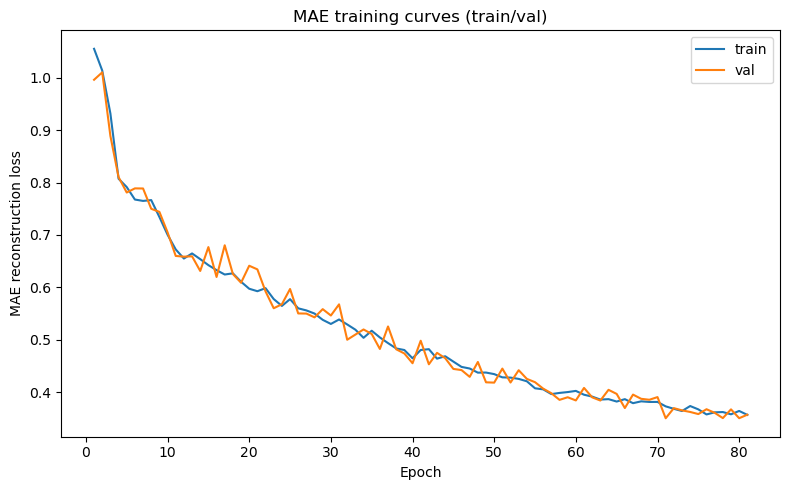

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader

# ---- dataset wrapper (reused) ----
class TilesDataset(Dataset):
    def __init__(self, items):  # each item: {'station','lat','lon','res','x' (1,128,128)}
        self.items = items
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        it = self.items[i]
        return torch.from_numpy(it['x']), it['station']  # model only needs x for loss

# ---- station-wise split for val ----
def split_items_by_station(items, val_frac=0.15, seed=0):
    sids = sorted(set(it['station'] for it in items))
    rng = np.random.default_rng(seed)
    k_val = max(1, int(len(sids) * val_frac))
    val_sids = set(rng.choice(sids, size=k_val, replace=False))
    tr = [it for it in items if it['station'] not in val_sids]
    va = [it for it in items if it['station'] in val_sids]
    return tr, va, val_sids

# ---- training with curves, early stopping, and (optional) LR plateau ----
def train_mae_with_curves(
    items_all,
    epochs=40,
    batch_size=16,
    embed_dim=64,
    mask_ratio=0.6,
    lr=1e-3,
    weight_decay=1e-4,
    device='cpu',
    seed=0,
    patience=8,
    use_plateau=True,
):
    torch.manual_seed(seed); np.random.seed(seed)

    # split by station (not by samples) to reduce leakage across resolutions
    items_tr, items_va, _ = split_items_by_station(items_all, val_frac=0.15, seed=seed)
    dl_tr = DataLoader(TilesDataset(items_tr), batch_size=batch_size, shuffle=True, num_workers=0)
    dl_va = DataLoader(TilesDataset(items_va), batch_size=batch_size, shuffle=False, num_workers=0)

    mae = TinyPatchMAE(patch_size=16, embed_dim=embed_dim, mask_ratio=mask_ratio).to(device)
    opt = torch.optim.AdamW(mae.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=3, verbose=False) if use_plateau else None

    best_val = float('inf'); best_state = None; bad = 0
    hist = []

    for ep in range(1, epochs+1):
        # ---- train ----
        mae.train(); train_sum=0.0; ntr=0
        for xb, _ in dl_tr:
            xb = xb.to(device)
            opt.zero_grad(set_to_none=True)
            loss = mae(xb)       # MAE returns masked-patch MSE
            loss.backward()
            torch.nn.utils.clip_grad_norm_(mae.parameters(), 1.0)
            opt.step()
            train_sum += float(loss) * xb.size(0); ntr += xb.size(0)
        train_loss = train_sum / max(1, ntr)

        # ---- validate ----
        mae.eval(); val_sum=0.0; nva=0
        with torch.no_grad():
            for xb, _ in dl_va:
                xb = xb.to(device)
                loss = mae(xb)
                val_sum += float(loss) * xb.size(0); nva += xb.size(0)
        val_loss = val_sum / max(1, nva)

        if sched is not None:
            sched.step(val_loss)

        hist.append({'epoch': ep, 'train_loss': train_loss, 'val_loss': val_loss})

        # early stopping
        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in mae.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience:
                print(f"Early stopping at epoch {ep} (best val {best_val:.4f})")
                break

     #   print(f"Epoch {ep:03d}/{epochs} - train {train_loss:.4f} - val {val_loss:.4f}")

    # load best
    if best_state is not None:
        mae.load_state_dict(best_state)

    hist_df = pd.DataFrame(hist)
    return mae, hist_df

# Each item will carry its resolution label (normalized) in 'res'.
items_all = []
for res_key, bucket in results_128.items():
    lab = _label_from_key(res_key)  # e.g., "0.25"
    # reuse your existing builder; returns dicts with station/lat/lon/x
    items = build_items_from_bucket(bucket, unique_latlon, latlon_to_station, var='elevation')
    for it in items:
        it = dict(it)  # copy
        it['res'] = lab
        items_all.append(it)


# ======== RUN: more epochs + plot curves ========
device = 'cpu'  # or 'cuda' if available
mae, hist_df = train_mae_with_curves(
    items_all,
    epochs=200,           # more epochs
    batch_size=16,
    embed_dim=64,
    mask_ratio=0.6,
    lr=1e-3,
    weight_decay=1e-4,
    device=device,
    seed=0,
    patience=10,         # be patient if training improves slowly
    use_plateau=True,
)

# ---- Plot training curves (one plot, two lines) ----
fig, ax = plt.subplots(figsize=(8,5))
ax.plot(hist_df['epoch'], hist_df['train_loss'], label='train')
ax.plot(hist_df['epoch'], hist_df['val_loss'],   label='val')
ax.set_xlabel('Epoch')
ax.set_ylabel('MAE reconstruction loss')
ax.set_title('MAE training curves (train/val)')
ax.legend()
plt.tight_layout()

In [54]:
import re
import numpy as np
import pandas as pd
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

# items_all must contain dicts like:
# {'station': str, 'lat': float, 'lon': float, 'res': '0.25', 'x': np.ndarray shape (1,128,128)}

class EncDataset(Dataset):
    def __init__(self, items): self.items = items
    def __len__(self): return len(self.items)
    def __getitem__(self, i):
        it = self.items[i]
        # return everything needed to reconstruct the row
        return torch.from_numpy(it['x']), it['station'], it['res'], float(it['lat']), float(it['lon'])

@torch.no_grad()
def encode_items_with_mae(mae, items, device=None, batch_size=64):
    if device is None:
        try:
            device = next(mae.parameters()).device
        except Exception:
            device = torch.device('cpu')
    dl = DataLoader(EncDataset(items), batch_size=batch_size, shuffle=False, num_workers=0)
    mae.eval()
    rows = []
    for xb, sids, ress, lats, lons in dl:
        xb = xb.to(device)
        z = mae.embed(xb).cpu().numpy().astype(np.float32)  # (B, D)
        for sid, res, la, lo, vec in zip(sids, ress, lats, lons, z):
            rows.append({
                'station': str(sid),
                'lat': float(la),
                'lon': float(lo),
                'res': str(res),
                'embedding': vec
            })
    return rows

# ---- Encode all items and build the LONG dataframe (one row per station×resolution) ----
rows = encode_items_with_mae(mae, items_all, device=None, batch_size=64)
df_mae_long = pd.DataFrame(rows)

# If there are accidental duplicates (same station & res), keep the first
df_mae_long = df_mae_long.drop_duplicates(subset=['station','res']).reset_index(drop=True)

# Expand the embedding vector to z_0..z_{D-1} columns
if len(df_mae_long):
    Z = np.stack(df_mae_long['embedding'].values)  # shape (N, D)
    zcols = [f"z_{i}" for i in range(Z.shape[1])]
    df_mae_long = pd.concat(
        [df_mae_long.drop(columns=['embedding']),
         pd.DataFrame(Z, columns=zcols)],
        axis=1
    )

def _norm_res(res: str) -> str:
    """
    Extract numeric part of the resolution label and format cleanly.
    Examples:
      "0.1x0.1" -> "0.1"
      "0.25"    -> "0.25"
      "3x3"     -> "3"
    """
    s = str(res)
    m = re.search(r'([0-9]*\.?[0-9]+)', s)
    if not m:
        return s.strip()
    v = float(m.group(1))
    return f"{v:g}"  # strip trailing zeros

def mae_station_wide(df_mae_long: pd.DataFrame) -> pd.DataFrame:
    """
    Convert LONG df (station, lat, lon, res, z_0..z_{D-1}) into
    a WIDE df with one row per station and columns like z1_0.1, z2_0.1, ...
    """
    if not {'station','res'}.issubset(df_mae_long.columns):
        raise ValueError("df_mae_long must include 'station' and 'res' columns.")
    zcols = [c for c in df_mae_long.columns if c.startswith('z_')]
    if not zcols:
        raise ValueError("No z_* columns found in df_mae_long.")

    base = df_mae_long.copy()
    base['station'] = base['station'].astype(str)
    base['res_clean'] = base['res'].apply(_norm_res)

    # 1-based z names: z_0 -> z1, z_1 -> z2, ...
    z_rename = {f"z_{i}": f"z{i+1}" for i in range(len(zcols))}
    zcols_sorted = sorted(zcols, key=lambda s: int(s.split('_')[1]))
    base = base[['station','lat','lon','res_clean'] + zcols_sorted].rename(columns=z_rename)

    # Long form: one row per (station, res, z_k)
    long = base.melt(
        id_vars=['station','lat','lon','res_clean'],
        value_vars=[z_rename[c] for c in zcols_sorted],
        var_name='zname',
        value_name='value'
    )

    # Feature name: z1_0.1, z2_0.1, ...
    long['feat'] = long['zname'] + '_' + long['res_clean']

    # Pivot to wide: one row per station (keep first lat/lon seen)
    wide = (long
            .pivot_table(index=['station','lat','lon'],
                         columns='feat', values='value', aggfunc='first')
            .reset_index())

    # Optional: sort columns by (res, z index)
    def _z_idx(name):
        m = re.search(r'^z(\d+)_', name)
        return int(m.group(1)) if m else 0
    def _res_val(name):
        m = re.search(r'_(\d+(?:\.\d+)?)$', name)
        return float(m.group(1)) if m else 0.0

    fixed = ['station','lat','lon']
    feat_cols = [c for c in wide.columns if c not in fixed]
    feat_cols_sorted = sorted(feat_cols, key=lambda n: (_res_val(n), _z_idx(n)))
    wide = wide[fixed + feat_cols_sorted]

    return wide

# ---- run it ----
df_enc_stations = mae_station_wide(df_mae_long)
print(df_enc_stations.shape)
df_enc_stations.head()


(180, 323)


feat,station,lat,lon,z1_0.1,z2_0.1,z3_0.1,z4_0.1,z5_0.1,z6_0.1,z7_0.1,...,z55_10,z56_10,z57_10,z58_10,z59_10,z60_10,z61_10,z62_10,z63_10,z64_10
0,1,60.155000,-1.140000,0.006284,-0.431933,0.121389,2.295490,0.079429,1.400957,-0.606175,...,0.976746,-1.178536,-0.775023,-0.752532,-0.007806,0.329035,-0.608987,-0.952683,0.137323,0.430276
1,10,63.425224,9.101504,-0.238161,-0.054045,-0.083631,1.516032,0.164484,2.210759,-0.163543,...,0.699729,-1.702050,-0.746106,-0.360524,0.239439,0.523771,-0.535255,-0.545682,0.044450,0.337743
2,100,50.708880,-2.764110,0.409273,-0.679301,0.158832,2.373583,0.110789,0.764653,-0.751243,...,0.272593,-1.298261,0.329351,-0.207175,0.445965,0.197773,-0.655232,0.210239,-0.260964,0.642289
3,105,50.969398,1.867720,-0.459354,0.185066,-0.458251,1.832972,0.148202,1.926265,0.007509,...,0.396152,-1.388934,-0.781526,-0.955977,0.620021,-0.217031,-0.099449,-0.330007,0.098382,0.273916
4,106,50.727380,1.577660,-0.139283,0.125526,-0.367565,3.241529,-0.039660,1.408710,-0.227243,...,0.333478,-1.415092,-0.673505,-0.830516,0.599565,-0.194375,0.099611,-0.222775,0.081616,0.147486


In [57]:
import re
import numpy as np
import pandas as pd

# --- helper to normalize a resolution key like "0.25x0.25" -> "0.25", "3x3" -> "3", "1.0" -> "1"
def _norm_res_label(res_key) -> str:
    s = str(res_key)
    m = re.search(r'([0-9]*\.?[0-9]+)', s)
    if not m:
        return s.strip()
    return f"{float(m.group(1)):g}"  # strip trailing .0

def build_df_geom_all(results_128, unique_latlon, latlon_to_station, var='elevation', res_keys=None):
    """
    For each resolution bucket in `results_128`, compute your tile metrics and
    return:
      - df_geom_long: rows = (station, res), columns = lat, lon, metrics...
      - df_geom_wide: rows = station, columns = <metric>_<res> (e.g., depth_mean_0.25)
    """
    if res_keys is None:
        res_keys = list(results_128.keys())

    frames = []
    for rk in res_keys:
        if rk not in results_128:
            continue
        try:
            dfg = build_df_geom(results_128, rk, unique_latlon, latlon_to_station, var=var)
            dfg['res'] = _norm_res_label(rk)
            frames.append(dfg)
            print(f"[ok] computed metrics for res={rk} → {len(dfg)} rows")
        except Exception as e:
            print(f"[warn] skipping res={rk}: {e}")

    if not frames:
        raise RuntimeError("No resolution produced metrics — check results_128 contents.")

    # ---- LONG: one row per station×res ----
    df_geom_long = pd.concat(frames, ignore_index=True)
    # keep a single (station, res) row (in case of duplicates)
    df_geom_long = df_geom_long.drop_duplicates(subset=['station','res']).reset_index(drop=True)

    # ---- WIDE: one row per station; metric columns with _<res> suffix ----
    metric_cols = [c for c in df_geom_long.columns if c not in ('station','lat','lon','res')]
    wide = df_geom_long.pivot(index=['station','lat','lon'], columns='res', values=metric_cols)

    # Flatten MultiIndex columns: (metric, res) -> metric_<res>
    wide.columns = [f"{met}_{res}" for (met, res) in wide.columns]
    df_geom_wide = wide.reset_index()

    return df_geom_long, df_geom_wide

# ---------- run it ----------
# results_128: {"0.1x0.1":[xr.Dataset,...], "0.25x0.25":[...], "1x1":[...], ...}
# unique_latlon, latlon_to_station already defined in your session.

df_geom_long, df_geom_wide = build_df_geom_all(
    results_128,
    unique_latlon=unique_latlon,
    latlon_to_station=latlon_to_station,
    var='elevation',
    res_keys=None  # or pass a specific list like ["0.1x0.1","0.25x0.25","1x1","3x3","10x10"]
)

print("LONG shape:", df_geom_long.shape)
print("WIDE shape:", df_geom_wide.shape)
print("WIDE example columns:", [c for c in df_geom_wide.columns[:15]])


[ok] computed metrics for res=0.1x0.1 → 180 rows
[ok] computed metrics for res=0.25x0.25 → 180 rows
[ok] computed metrics for res=1.0x1.0 → 180 rows
[ok] computed metrics for res=3.0x3.0 → 180 rows
[ok] computed metrics for res=10.0x10.0 → 180 rows
LONG shape: (900, 15)
WIDE shape: (180, 58)
WIDE example columns: ['station', 'lat', 'lon', 'sea_frac_0.1', 'sea_frac_0.25', 'sea_frac_1', 'sea_frac_10', 'sea_frac_3', 'depth_mean_0.1', 'depth_mean_0.25', 'depth_mean_1', 'depth_mean_10', 'depth_mean_3', 'depth_std_0.1', 'depth_std_0.25']


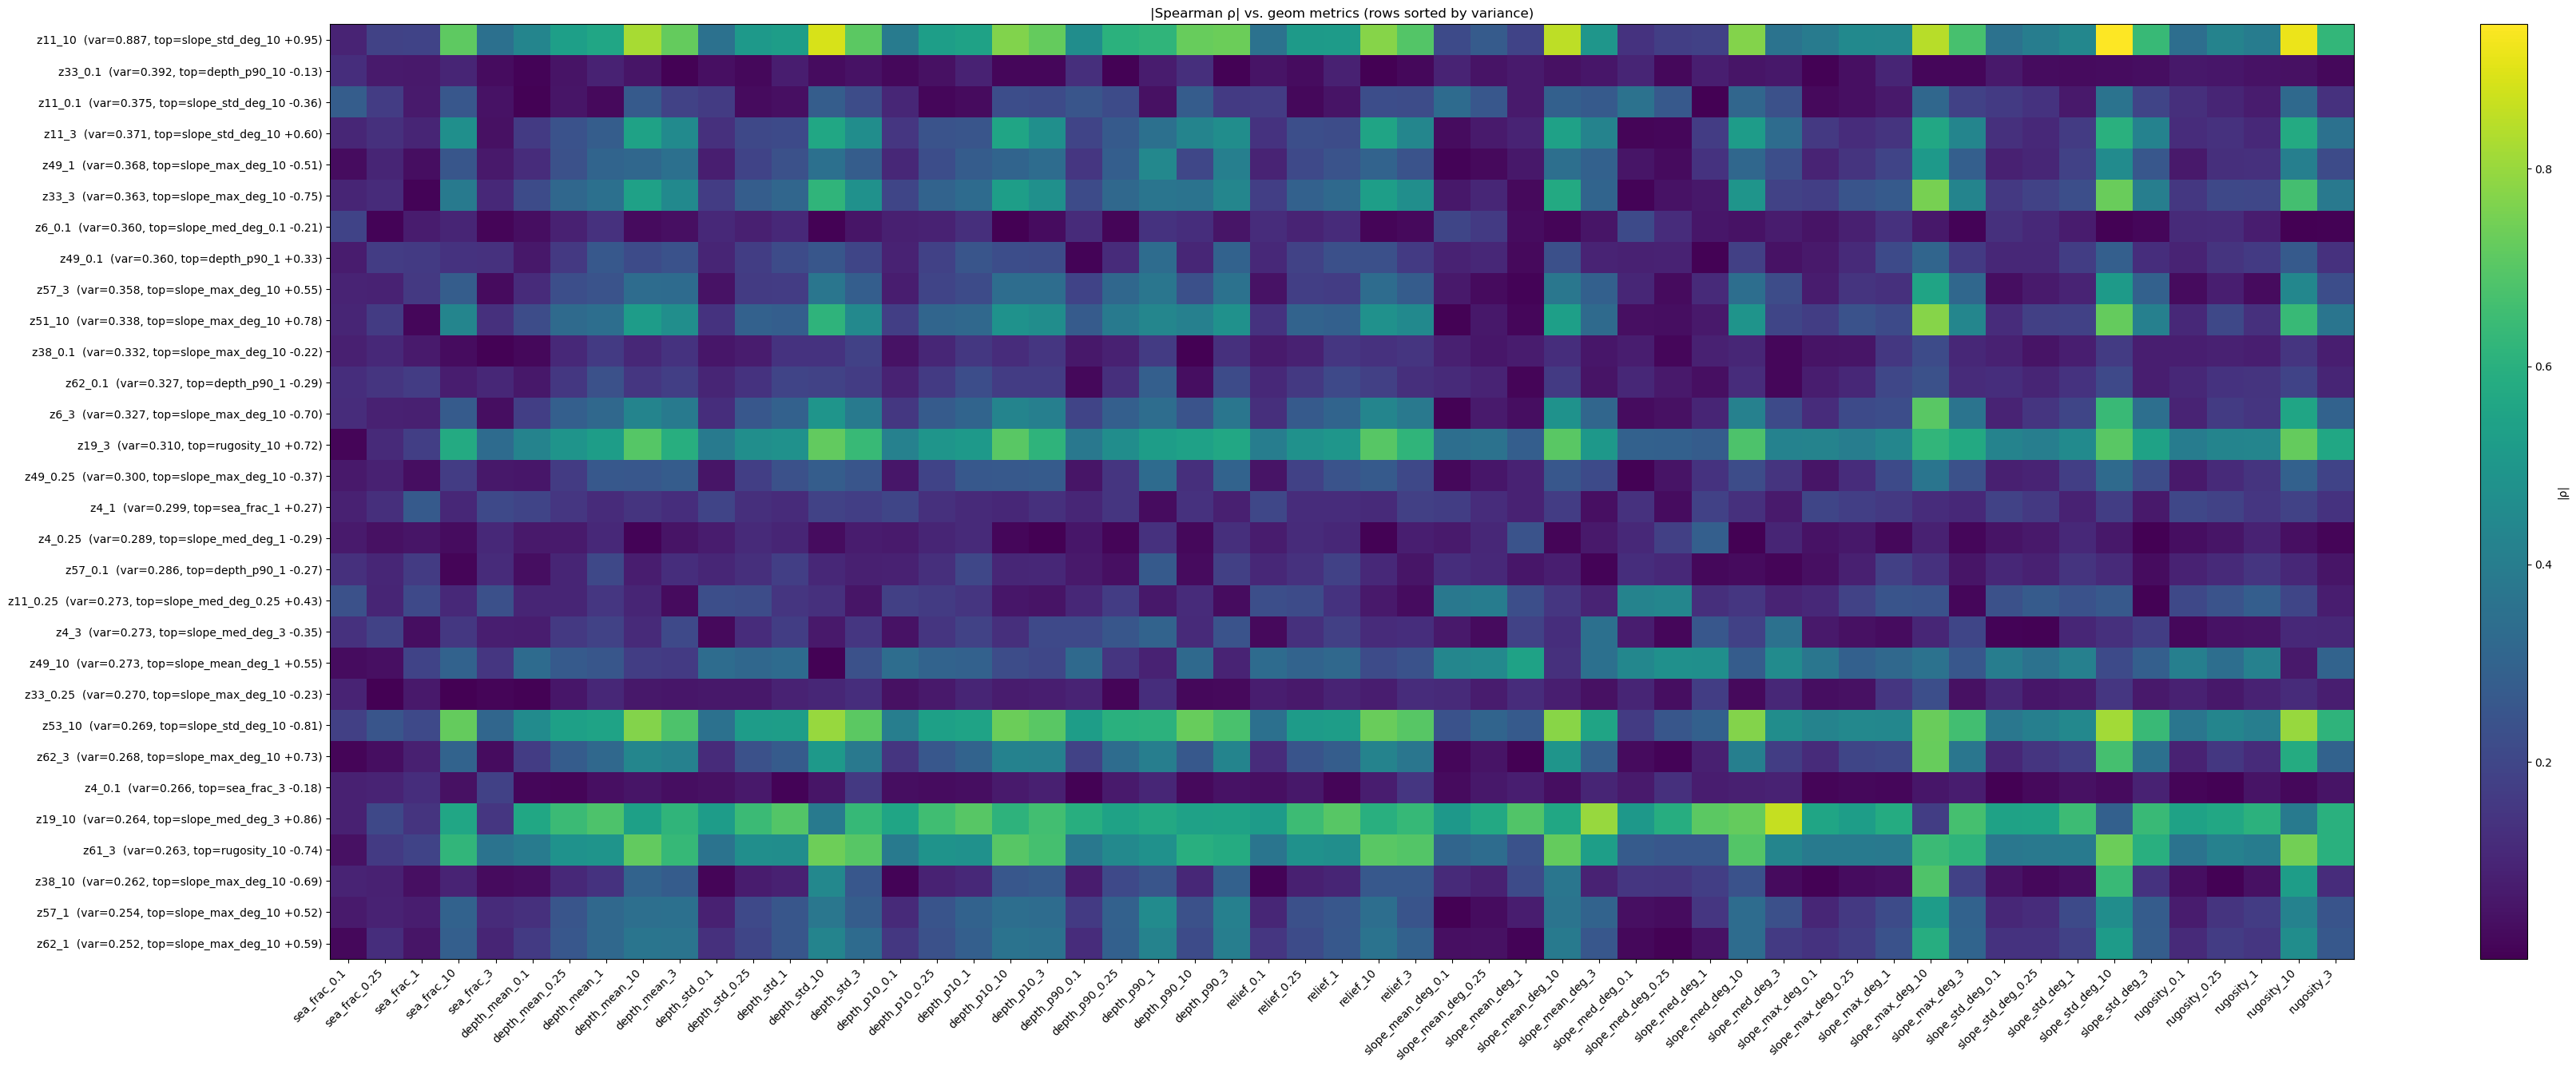

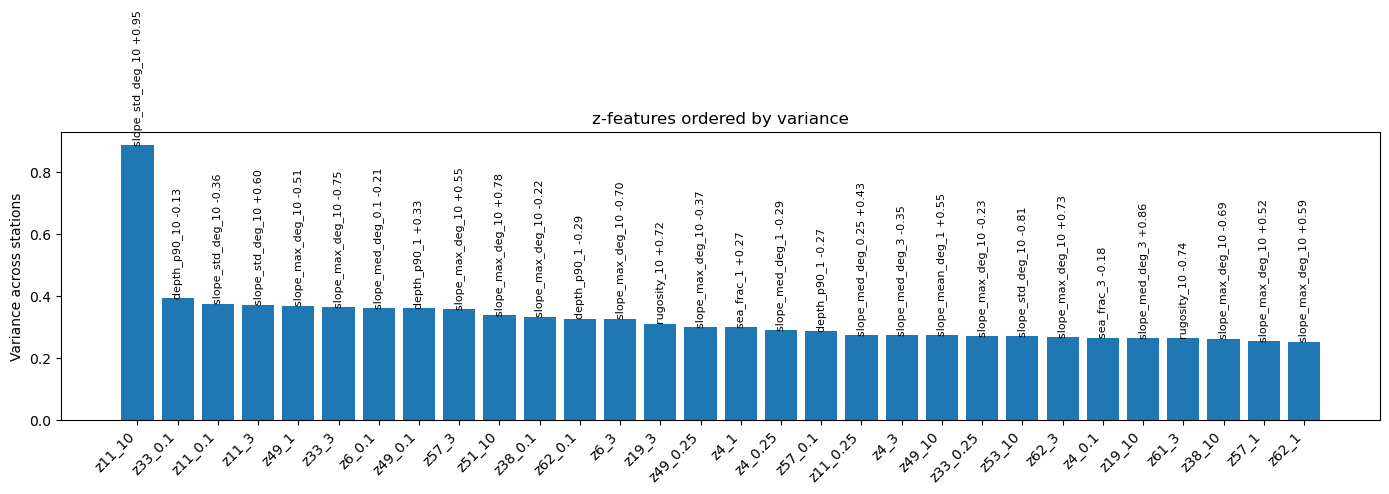

In [65]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- which geom metrics to consider (will auto-filter to those present) ---
GEOM_METRICS = [
   'sea_frac_0.1', 'sea_frac_0.25', 'sea_frac_1',
       'sea_frac_10', 'sea_frac_3', 'depth_mean_0.1', 'depth_mean_0.25',
       'depth_mean_1', 'depth_mean_10', 'depth_mean_3', 'depth_std_0.1',
       'depth_std_0.25', 'depth_std_1', 'depth_std_10', 'depth_std_3',
       'depth_p10_0.1', 'depth_p10_0.25', 'depth_p10_1', 'depth_p10_10',
       'depth_p10_3', 'depth_p90_0.1', 'depth_p90_0.25', 'depth_p90_1',
       'depth_p90_10', 'depth_p90_3', 'relief_0.1', 'relief_0.25', 'relief_1',
       'relief_10', 'relief_3', 'slope_mean_deg_0.1', 'slope_mean_deg_0.25',
       'slope_mean_deg_1', 'slope_mean_deg_10', 'slope_mean_deg_3',
       'slope_med_deg_0.1', 'slope_med_deg_0.25', 'slope_med_deg_1',
       'slope_med_deg_10', 'slope_med_deg_3', 'slope_max_deg_0.1',
       'slope_max_deg_0.25', 'slope_max_deg_1', 'slope_max_deg_10',
       'slope_max_deg_3', 'slope_std_deg_0.1', 'slope_std_deg_0.25',
       'slope_std_deg_1', 'slope_std_deg_10', 'slope_std_deg_3',
       'rugosity_0.1', 'rugosity_0.25', 'rugosity_1', 'rugosity_10',
       'rugosity_3'
]

def _is_zcol(c: str) -> bool:
    # matches z#_res like: z1_0.1, z12_3, z7_0.25
    return bool(re.match(r'^z\d+_[0-9]+(?:\.[0-9]+)?$', c))

def _z_index(c: str) -> int:
    m = re.match(r'^z(\d+)_', c)
    return int(m.group(1)) if m else 0

def _res_label(c: str) -> str:
    m = re.search(r'_(\d+(?:\.\d+)?)$', c)
    return m.group(1) if m else ''

def variance_and_correlations(df_enc_stations: pd.DataFrame,
                              df_geom: pd.DataFrame,
                              geom_metrics=GEOM_METRICS,
                              corr_method='spearman'):
    # pick z and geom columns
    zcols = [c for c in df_enc_stations.columns if _is_zcol(c)]
    if not zcols:
        raise ValueError("No z*_* columns found in df_enc_stations (expected like 'z1_0.1').")
    geom_cols = [c for c in geom_metrics if c in df_geom.columns]
    if not geom_cols:
        raise ValueError("None of the requested geom metrics are present in df_geom.")

    # align by station
    left  = df_enc_stations[['station'] + zcols].copy()
    right = df_geom[['station'] + geom_cols].copy()
    left['station']  = left['station'].astype(str)
    right['station'] = right['station'].astype(str)
    merged = left.merge(right, on='station', how='inner')
    if merged.empty:
        raise ValueError("No overlapping stations between df_enc_stations and df_geom.")

    # variance of each z (across stations)
    z_var = merged[zcols].var(axis=0, ddof=1).astype(float)  # pandas variance

    # Spearman correlations
    corr = merged[zcols + geom_cols].corr(method=corr_method)
    ZxG = corr.loc[zcols, geom_cols]  # rows=z, cols=geom

    # top geom metric per z (by |rho|)
    top_geom_idx = ZxG.abs().values.argmax(axis=1)
    top_geom = [geom_cols[j] for j in top_geom_idx]
    top_rho  = [ZxG.values[i, j] for i, j in enumerate(top_geom_idx)]

    # assemble summary
    summary = pd.DataFrame({
        'z': zcols,
        'variance': z_var.values,
        'res': [_res_label(z) for z in zcols],
        'z_idx': [_z_index(z) for z in zcols],
        'top_geom': top_geom,
        'top_rho': top_rho,
        'top_abs_rho': np.abs(top_rho),
    }).sort_values('variance', ascending=False).reset_index(drop=True)

    return ZxG, summary

def plot_heatmap_ordered_by_variance(ZxG: pd.DataFrame, summary: pd.DataFrame,
                                     topk=30, annotate_threshold=(30, 12)):
    """Heatmap of |ρ|, rows sorted by variance; ylabels include var + top metric."""
    # pick top-k by variance
    take = summary.head(min(topk, len(summary))).copy()
    # build y-axis labels showing variance + top metric and rho
    ylabels = [
        f"{row.z}  (var={row.variance:.3f}, top={row.top_geom} {row.top_rho:+.2f})"
        for _, row in take.iterrows()
    ]
    Z_sub = ZxG.loc[take['z'], :].abs()

    # figure
    fig, ax = plt.subplots(figsize=(max(6, 0.6*Z_sub.shape[1]+3), max(6, 0.35*Z_sub.shape[0]+3)))
    im = ax.imshow(Z_sub.values, aspect='auto')
    ax.set_xticks(range(Z_sub.shape[1])); ax.set_xticklabels(Z_sub.columns, rotation=45, ha='right')
    ax.set_yticks(range(Z_sub.shape[0])); ax.set_yticklabels(ylabels)
    ax.set_title("|Spearman ρ| vs. geom metrics (rows sorted by variance)")
    cb = fig.colorbar(im, ax=ax, label='|ρ|')

    # annotate cells if matrix is small enough
    if Z_sub.shape[0] <= annotate_threshold[0] and Z_sub.shape[1] <= annotate_threshold[1]:
        for i in range(Z_sub.shape[0]):
            for j in range(Z_sub.shape[1]):
                ax.text(j, i, f"{Z_sub.values[i, j]:.2f}", ha='center', va='center', fontsize=8)
    plt.tight_layout()
    return fig

def plot_variance_bars(summary: pd.DataFrame, topk=30):
    """Optional: bar chart of variances with top metric annotated."""
    take = summary.head(min(topk, len(summary))).copy()
    x = np.arange(len(take))
    fig, ax = plt.subplots(figsize=(max(8, 0.4*len(take)+2), 5))
    ax.bar(x, take['variance'].values)
    ax.set_xticks(x)
    ax.set_xticklabels(take['z'].values, rotation=45, ha='right')
    ax.set_ylabel('Variance across stations')
    ax.set_title('z-features ordered by variance')

    # annotate with top metric
    for xi, (tg, tr) in enumerate(zip(take['top_geom'].values, take['top_rho'].values)):
        ax.text(xi, take['variance'].values[xi], f"{tg} {tr:+.2f}", ha='center', va='bottom', fontsize=8, rotation=90)
    plt.tight_layout()
    return fig

# ===== run =====
ZxG, summary = variance_and_correlations(df_enc_stations, df_geom_wide, geom_metrics=GEOM_METRICS, corr_method='spearman')

# Heatmap: top 30 z's by variance (edit topk as you wish)
fig1 = plot_heatmap_ordered_by_variance(ZxG, summary, topk=30)

# Optional: bar chart (comment out if you only want one figure)
fig2 = plot_variance_bars(summary, topk=30)


In [67]:
import re
import numpy as np
import pandas as pd

def _is_zcol(c: str) -> bool:
    # matches names like z1_0.1, z12_3, z7_0.25, etc.
    return bool(re.match(r'^z\d+_[0-9]+(?:\.[0-9]+)?$', c))

def select_top_variance_z(df_enc_stations: pd.DataFrame, k: int = 20, summary: pd.DataFrame | None = None):
    """
    Returns:
      df_top  : df with ['station', ('lat','lon' if present), top-k z columns]
      z_var   : pd.Series of variances for all z columns (descending)
      top_cols: list of selected z column names
    """
    # 1) identify z columns
    zcols = [c for c in df_enc_stations.columns if _is_zcol(c)]
    if not zcols:
        # fallback: any 'z' columns
        zcols = [c for c in df_enc_stations.columns if c.startswith('z')]
    if not zcols:
        raise ValueError("No z*_* columns found in df_enc_stations.")

    # 2) pick top-k either from summary (if provided) or by recomputing variance
    if summary is not None and {'z','variance'}.issubset(summary.columns):
        top_cols = summary.sort_values('variance', ascending=False)['z'].head(k).tolist()
        # keep only those that exist in this df (safety)
        top_cols = [c for c in top_cols if c in zcols]
        # if fewer than k (e.g., after filtering), fill from raw variance
        if len(top_cols) < k:
            z_var_fallback = df_enc_stations[zcols].var(axis=0, ddof=1).sort_values(ascending=False)
            for c in z_var_fallback.index:
                if c not in top_cols:
                    top_cols.append(c)
                if len(top_cols) >= k:
                    break
        # compute variance series (use actual values from df)
        z_var = df_enc_stations[zcols].var(axis=0, ddof=1).sort_values(ascending=False)
    else:
        z_var = df_enc_stations[zcols].var(axis=0, ddof=1).sort_values(ascending=False)
        top_cols = z_var.head(k).index.tolist()

    # 3) build filtered dataframe
    keep = ['station'] + [c for c in ('lat','lon') if c in df_enc_stations.columns] + top_cols
    df_top = df_enc_stations[keep].copy()

    return df_top, z_var, top_cols

# ---- use it ----
# If you ran the variance+correlation code earlier and have `summary`, pass it; otherwise omit it.
df_top20, z_variance, top_cols = select_top_variance_z(df_enc_stations, k=20, summary=None)



In [ ]:
features_df = (
    features_df
    .drop(columns=["latitude", "longitude"])
    .rename(columns={
        "station_latitude": "latitude",
        "station_longitude": "longitude"
    })
)

In [84]:
# rename columns
df = df_top20.rename(columns={'lat': 'latitude', 'lon': 'longitude'})
df = df.drop(columns=['station'], errors='ignore')

In [85]:
df["latitude"]  = df["latitude"].round(2)
df["longitude"] = df["longitude"].round(2)
features_df["latitude"]  = features_df["latitude"].round(2)
features_df["longitude"] = features_df["longitude"].round(2)

#summary_df = df[["latitude", "longitude"] + [c for c in df.columns if c.startswith("pca_")]]

In [87]:
merged = df.merge(features_df, on=["latitude", "longitude"], how="inner")

In [89]:
merged.columns

Index(['latitude', 'longitude', 'z11_10', 'z33_0.1', 'z11_0.1', 'z11_3',
       'z49_1', 'z33_3', 'z6_0.1', 'z49_0.1', 'z57_3', 'z51_10', 'z38_0.1',
       'z62_0.1', 'z6_3', 'z19_3', 'z49_0.25', 'z4_1', 'z4_0.25', 'z57_0.1',
       'z11_0.25', 'z4_3', 'station', 'valid_time', 'u10', 'v10', 'd2m', 't2m',
       'msl', 'sst', 'sp', 'tp', 'mwd', 'mwp', 'swh', 'wind_speed',
       'd_wind_1h', 'd_wind_6h', 'd_sp_1h', 'd_sp_6h', 'tide_range_12h',
       'tide_lag0h', 'tide_lag1h', 'tide_lag6h', 'tau_x', 'tau_y', 'tau_mag',
       'tau_d1h', 'tau_d6h', 'residual', 'station_latitude',
       'station_longitude'],
      dtype='object')

# Train on full

In [90]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
RANDOM_SEED=42

In [91]:
# 2) Random 10% sample
sample_frac = 0.1
merged = merged.sample(frac=sample_frac, random_state=RANDOM_SEED)

In [113]:
def stats(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred, squared=False)
    r2   = r2_score(y_true, y_pred)
    denom = np.where(np.abs(y_true) < 1e-8, np.nan, np.abs(y_true))
    mape = np.nanmean(np.abs((y_true - y_pred) / denom)) * 100.0
    return {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE_%": mape}

rng = np.random.default_rng(RANDOM_SEED)
stations = np.array(sorted( merged["station"].unique()))
perm = rng.permutation(stations)

predictors = [
    col for col in merged.columns
    if col not in ["latitude", "longitude", "valid_time", "residual", "station"]
]

n = len(perm)
n_train = int(round(0.70 * n))
n_val   = int(round(0.10 * n))
n_test  = n - n_train - n_val

train_stn = set(perm[:n_train])
val_stn   = set(perm[n_train:n_train + n_val])
test_stn  = set(perm[n_train + n_val:])

m_train = merged["station"].isin(train_stn)
m_val   = merged["station"].isin(val_stn)
m_test  = merged["station"].isin(test_stn)

X_cols = predictors  # all other variables as predictors

X_train, y_train =  merged.loc[m_train, X_cols],  merged.loc[m_train, target]
X_val,   y_val   =  merged.loc[m_val,   X_cols],  merged.loc[m_val,   target]
X_test,  y_test  =  merged.loc[m_test,  X_cols],  merged.loc[m_test,  target]

In [120]:
import numpy as np
import pandas as pd

# -------- 1) Build a station ANCHOR (keep all stations; prefer one with coords) --------
def _safe_subset(df, cols):
    return df[[c for c in cols if c in df.columns]].copy()

def build_anchor_df():
    # Gather candidates if they exist in the workspace
    candidates = []
    for name in ["df_enc_stations", "df_geom_wide", "df_geom_long", "df_mae_long", "merged"]:
        if name in globals():
            df = globals()[name]
            if isinstance(df, pd.DataFrame) and "station" in df.columns:
                cols = ["station","latitude","longitude"]
                candidates.append(_safe_subset(df, cols))
    if not candidates:
        raise RuntimeError("No station table found. Ensure at least one of df_enc_stations/df_geom_wide/merged exists.")

    anchor = pd.concat(candidates, ignore_index=True)
    anchor["station"] = anchor["station"].astype(str)
    # keep first non-null coords per station if available
    anchor = (anchor
              .sort_values(["station"])
              .drop_duplicates("station", keep="first")
              .reset_index(drop=True))
    return anchor

anchor_df = build_anchor_df()
print(f"[anchor] unique stations: {anchor_df['station'].nunique()}")

# -------- 2) Make station-wise splits from the ANCHOR (not from merged) --------
def station_splits_from_anchor(anchor_df, train=0.70, val=0.10, seed=42):
    rng = np.random.default_rng(seed)
    stations = np.array(sorted(anchor_df["station"].astype(str).unique()))
    perm = rng.permutation(stations)
    n = len(perm)
    n_train = int(round(train * n))
    n_val   = int(round(val   * n))
    n_test  = n - n_train - n_val
    train_stn = set(perm[:n_train])
    val_stn   = set(perm[n_train:n_train+n_val])
    test_stn  = set(perm[n_train+n_val:])
    return train_stn, val_stn, test_stn

RANDOM_SEED = 42  # or your existing seed
train_stn, val_stn, test_stn = station_splits_from_anchor(anchor_df, train=0.70, val=0.10, seed=RANDOM_SEED)
print(f"[split] train/val/test stations: {len(train_stn)}/{len(val_stn)}/{len(test_stn)}")

# -------- 3) Apply splits to MERGED, but report what's missing --------
merged = merged.copy()
merged["station"] = merged["station"].astype(str)

S_anchor = set(anchor_df["station"])
S_merged = set(merged["station"])
missing_in_merged = sorted(S_anchor - S_merged)
if missing_in_merged:
    print(f"[warn] {len(missing_in_merged)} anchor stations have no rows in `merged` "
          f"(e.g., {missing_in_merged[:10]}{'...' if len(missing_in_merged)>10 else ''}). "
          "They stay in the split counts, but won’t appear in X/y until you left-merge features/time series.")

m_train = merged["station"].isin(train_stn)
m_val   = merged["station"].isin(val_stn)
m_test  = merged["station"].isin(test_stn)

print(f"[rows] train/val/test rows in merged: {m_train.sum()}/{m_val.sum()}/{m_test.sum()}")

# -------- 4) Build X/y using the SAME predictors as before --------
# target must exist (e.g., target = 'residual')
predictors = [c for c in merged.columns if c not in ["latitude","longitude","valid_time","residual","station", "station_laitude", "station_longitude"]]

X_train, y_train = merged.loc[m_train, predictors], merged.loc[m_train, target]
X_val,   y_val   = merged.loc[m_val,   predictors], merged.loc[m_val,   target]
X_test,  y_test  = merged.loc[m_test,  predictors], merged.loc[m_test,  target]

[anchor] unique stations: 180
[split] train/val/test stations: 126/18/36
[warn] 35 anchor stations have no rows in `merged` (e.g., ['114', '115', '116', '117', '130', '135', '151', '168', '169', '170']...). They stay in the split counts, but won’t appear in X/y until you left-merge features/time series.
[rows] train/val/test rows in merged: 1491459/210761/390869


[anchor] stations: 180
split
train    126
test      36
val       18
Name: count, dtype: int64


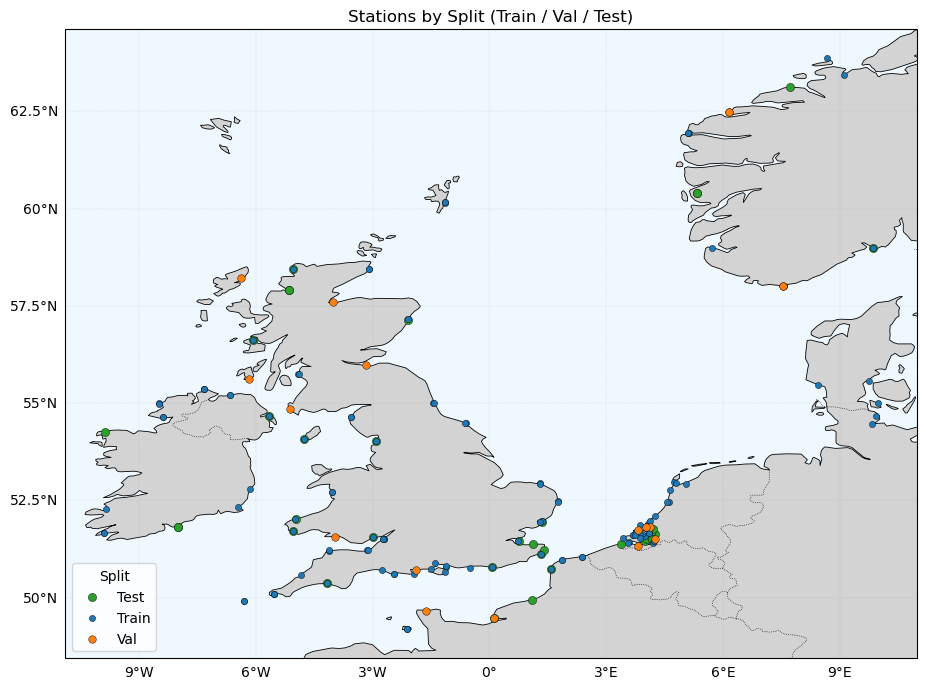

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --- robust anchor from your xarray mapping ---
def to_minus180_180(lon):
    lon = np.asarray(lon, dtype=float)
    return ((lon + 180.0) % 360.0) - 180.0

# latlon_to_station: {(lat, lon) -> station_id}  (you created this earlier)
anchor_df = pd.DataFrame(
    [{'station': str(int(stn)), 'latitude': float(lat), 'longitude': float(lon)}
     for (lat, lon), stn in latlon_to_station.items()]
).drop_duplicates('station')

# normalize longitudes
anchor_df['longitude'] = to_minus180_180(anchor_df['longitude'])
anchor_df = anchor_df.sort_values('station').reset_index(drop=True)
print("[anchor] stations:", anchor_df['station'].nunique())

# --- reuse your splits; if not defined, make them now ---
def station_splits_from_anchor(anchor_df, train=0.70, val=0.10, seed=42):
    rng = np.random.default_rng(seed)
    stations = np.array(sorted(anchor_df['station'].astype(str).unique()))
    perm = rng.permutation(stations)
    n = len(perm); n_train = int(round(train*n)); n_val = int(round(val*n)); n_test = n-n_train-n_val
    return set(perm[:n_train]), set(perm[n_train:n_train+n_val]), set(perm[n_train+n_val:])

try:
    train_stn, val_stn, test_stn
except NameError:
    train_stn, val_stn, test_stn = station_splits_from_anchor(anchor_df, train=0.70, val=0.10, seed=42)

# --- build plotting table from anchor (no dropouts) ---
st_meta = anchor_df.copy()
def split_label(s):
    if s in train_stn: return "train"
    if s in val_stn:   return "val"
    if s in test_stn:  return "test"
    return "unknown"
st_meta['split'] = st_meta['station'].apply(split_label)

print(st_meta['split'].value_counts())

# --- map extent with padding ---
lon_min, lon_max = st_meta['longitude'].min(), st_meta['longitude'].max()
lat_min, lat_max = st_meta['latitude'].min(),  st_meta['latitude'].max()
d_lon = (lon_max - lon_min) if lon_max > lon_min else 1.0
d_lat = (lat_max - lat_min) if lat_max > lat_min else 1.0
pad = 0.05  # small pad since it’s global-ish now
extent = [lon_min - pad*d_lon, lon_max + pad*d_lon,
          lat_min - pad*d_lat, lat_max + pad*d_lat]

# --- plot ---
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(11, 7))
ax = plt.axes(projection=proj)
ax.set_extent(extent, crs=proj)
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle="--")
gl.right_labels = False; gl.top_labels = False

styles = {"train": dict(color="tab:blue", s=20),
          "val":   dict(color="tab:orange", s=30),
          "test":  dict(color="tab:green", s=35),
          "unknown": dict(color="gray", s=20)}

for split, df_s in st_meta.groupby('split'):
    ax.scatter(df_s['longitude'], df_s['latitude'],
               transform=proj, edgecolor="k", linewidth=0.3,
               zorder=5, label=split.capitalize(), **styles.get(split, styles['unknown']))

ax.legend(loc="lower left", title="Split")
ax.set_title("Stations by Split (Train / Val / Test)")
plt.tight_layout()
plt.show()


In [137]:
# --- Tail-aware training & evaluation -----------------------------------------
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

# --- helpers (as before) ---
def pearson_r(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if y_true.size < 2 or np.isclose(y_true.std(), 0) or np.isclose(y_pred.std(), 0):
        return np.nan
    return float(np.corrcoef(y_true, y_pred)[0, 1])

def eval_R2_R4(y_true, y_pred):
    r = pearson_r(y_true, y_pred)
    return {"R2": (r**2) if np.isfinite(r) else np.nan,
            "R4": (r**4) if np.isfinite(r) else np.nan}

def make_tail_weights(y, q=0.90, w_tail=5.0, p=1.0):
    """
    Upweight the largest |y| values: weight = w_tail * (|y|/t)^p for |y| >= t,
    else weight = 1. Returns (weights, threshold t).
    """
    a = np.abs(np.asarray(y, float))
    t = np.quantile(a, q)
    w = np.ones_like(a, dtype=float)
    tail = a >= t
    if np.all(~tail):  # safety
        return w, t
    w[tail] = w_tail * (a[tail] / (t + 1e-12))**p
    return w, t

# ---------- Build numeric matrices (reuse your predictors / masks / target) ----------
num_cols = [c for c in predictors if pd.api.types.is_numeric_dtype(merged[c])]
X_train = merged.loc[m_train, num_cols]
X_val   = merged.loc[m_val,   num_cols]
X_test  = merged.loc[m_test,  num_cols]

y_train = merged.loc[m_train, target].astype(float).values
y_val   = merged.loc[m_val,   target].astype(float).values
y_test  = merged.loc[m_test,  target].astype(float).values

# Drop constant / all-NaN cols
good = [c for c in X_train.columns if X_train[c].notna().any() and X_train[c].nunique(dropna=True) > 1]
X_train, X_val, X_test = X_train[good], X_val[good], X_test[good]

# ---------- Tail weights (focus on extremes) ----------
w_train, tail_thr = make_tail_weights(y_train, q=0.90, w_tail=5.0, p=1.0)
print(f"[tail] using |y| threshold t={tail_thr:.4g}; ~{(np.abs(y_train)>=tail_thr).mean()*100:.1f}% of train upweighted")

# ---------- Model ----------
RANDOM_SEED = 42
model = XGBRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    n_jobs=4,
    random_state=RANDOM_SEED,
    tree_method="hist",
)

# Fit with sample weights; some versions support eval_sample_weight
fit_kwargs = dict(
    X=X_train, y=y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
    sample_weight=w_train,
)
try:
    fit_kwargs["eval_sample_weight"] = [w_train, np.ones_like(y_val)]
except Exception:
    pass

model.fit(**fit_kwargs)

# ---------- Predictions ----------
yhat_tr = model.predict(X_train)
yhat_va = model.predict(X_val)
yhat_te = model.predict(X_test)

# ---------- Metrics: overall & tail-only ----------
# Overall
m_tr = {**eval_R2_R4(y_train, yhat_tr), "sklearn_R2": r2_score(y_train, yhat_tr) if len(y_train) else np.nan}
m_va = {**eval_R2_R4(y_val,   yhat_va), "sklearn_R2": r2_score(y_val,   yhat_va) if len(y_val)   else np.nan}
m_te = {**eval_R2_R4(y_test,  yhat_te), "sklearn_R2": r2_score(y_test,  yhat_te) if len(y_test)  else np.nan}

# Tail-only (use the SAME threshold computed on training)
tail_tr = np.abs(y_train) >= tail_thr
tail_va = np.abs(y_val)   >= tail_thr
tail_te = np.abs(y_test)  >= tail_thr

mt_tr = eval_R2_R4(y_train[tail_tr], yhat_tr[tail_tr]) if tail_tr.any() else {"R2": np.nan, "R4": np.nan}
mt_va = eval_R2_R4(y_val[tail_va],   yhat_va[tail_va]) if tail_va.any() else {"R2": np.nan, "R4": np.nan}
mt_te = eval_R2_R4(y_test[tail_te],  yhat_te[tail_te]) if tail_te.any() else {"R2": np.nan, "R4": np.nan}

print("\nXGBoost (tail-weighted)")
print("--- Overall ---")
print("Train:", m_tr); print("Val:", m_va); print("Test:", m_te)
print("\n--- Tail (|y| >= train 90th pct) ---")
print("Train tail:", mt_tr, f"(n={tail_tr.sum()})")
print("Val   tail:", mt_va, f"(n={tail_va.sum()})")
print("Test  tail:", mt_te, f"(n={tail_te.sum()})")

# ---------- Per-station tail R² on test ----------
test_idx = merged.index[m_test]
te_df = merged.loc[test_idx, ['station']].copy()
te_df['y_true'] = y_test
te_df['y_pred'] = yhat_te
te_df['is_tail'] = (np.abs(y_test) >= tail_thr)

rows = []
for sid, g in te_df.groupby('station'):
    g_tail = g[g['is_tail']]
    if len(g_tail) >= 5 and np.isfinite(g_tail['y_true'].std()) and np.isfinite(g_tail['y_pred'].std()):
        r = pearson_r(g_tail['y_true'], g_tail['y_pred'])
        rows.append({'station': str(sid), 'n_tail': len(g_tail),
                     'R_tail': r, 'R2_tail': (r**2) if np.isfinite(r) else np.nan})
    else:
        rows.append({'station': str(sid), 'n_tail': len(g_tail),
                     'R_tail': np.nan, 'R2_tail': np.nan})

st_tail_scores = pd.DataFrame(rows).sort_values('R2_tail', ascending=False).reset_index(drop=True)
print("\nPer-station tail R² (top 10):")
print(st_tail_scores.head(10))


[tail] using |y| threshold t=0.3371; ~10.0% of train upweighted


TypeError: XGBModel.fit() got an unexpected keyword argument 'eval_sample_weight'

In [125]:
# pip install xgboost
import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

# --- helpers ---
def pearson_r(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    if y_true.size == 0 or np.allclose(y_true.std(), 0):
        return np.nan
    r = np.corrcoef(y_true, y_pred)[0, 1]
    return float(r)

def eval_R2_R4(y_true, y_pred):
    r = pearson_r(y_true, y_pred)
    return {"R2": (r**2) if np.isfinite(r) else np.nan,
            "R4": (r**4) if np.isfinite(r) else np.nan}

# ensure purely numeric feature matrix (drop non-numeric sneaking in)
num_cols = [c for c in predictors if pd.api.types.is_numeric_dtype(merged[c])]
X_train = merged.loc[m_train, num_cols]
X_val   = merged.loc[m_val,   num_cols]
X_test  = merged.loc[m_test,  num_cols]

y_train = merged.loc[m_train, target].astype(float)
y_val   = merged.loc[m_val,   target].astype(float)
y_test  = merged.loc[m_test,  target].astype(float)

# (optional) drop constant/all-NaN columns to be extra safe
good = [c for c in X_train.columns if X_train[c].notna().any() and X_train[c].nunique(dropna=True) > 1]
X_train, X_val, X_test = X_train[good], X_val[good], X_test[good]

# --- model (small, with early stopping) ---
RANDOM_SEED = 42
model = XGBRegressor(
    n_estimators=1500,        # early stopping will pick < this
    learning_rate=0.03,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    n_jobs=4,
    random_state=RANDOM_SEED,
    tree_method="hist",       # memory-friendly
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)

# --- predictions ---
yhat_tr = model.predict(X_train)
yhat_va = model.predict(X_val)
yhat_te = model.predict(X_test)

# --- metrics ---
# (1) classic sklearn R^2 (optional, for reference)
r2_tr = r2_score(y_train, yhat_tr) if len(y_train) else np.nan
r2_va = r2_score(y_val,   yhat_va) if len(y_val)   else np.nan
r2_te = r2_score(y_test,  yhat_te) if len(y_test)  else np.nan

# (2) requested R2 and R4 (based on Pearson correlation)
m_tr = eval_R2_R4(y_train, yhat_tr)
m_va = eval_R2_R4(y_val,   yhat_va)
m_te = eval_R2_R4(y_test,  yhat_te)

print("XGBoost with station-wise split")
print("\n--- Train ---")
print({**m_tr, "sklearn_R2": r2_tr})
print("\n--- Val ---")
print({**m_va, "sklearn_R2": r2_va})
print("\n--- Test ---")
print({**m_te, "sklearn_R2": r2_te})

# (optional) top features
imp = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("\nTop 20 features:")
print(imp.head(20))

XGBoost with station-wise split

--- Train ---
{'R2': 0.2800890131183495, 'R4': 0.07844985526961096, 'sklearn_R2': 0.27509117917822223}

--- Val ---
{'R2': 0.09512182534208649, 'R4': 0.009048161656410408, 'sklearn_R2': 0.0950621329438861}

--- Test ---
{'R2': 0.18776101916508656, 'R4': 0.035254200317912, 'sklearn_R2': 0.1870523473007757}

Top 20 features:
msl                 0.324737
sp                  0.144027
tau_x               0.064651
tide_range_12h      0.034217
station_latitude    0.034043
tau_y               0.033169
u10                 0.031910
t2m                 0.029680
d2m                 0.028980
mwd                 0.027468
d_sp_6h             0.023421
v10                 0.023238
sst                 0.019301
swh                 0.018527
mwp                 0.017790
tide_lag0h          0.017775
d_sp_1h             0.017247
tide_lag6h          0.017110
tp                  0.016495
wind_speed          0.015434
dtype: float32


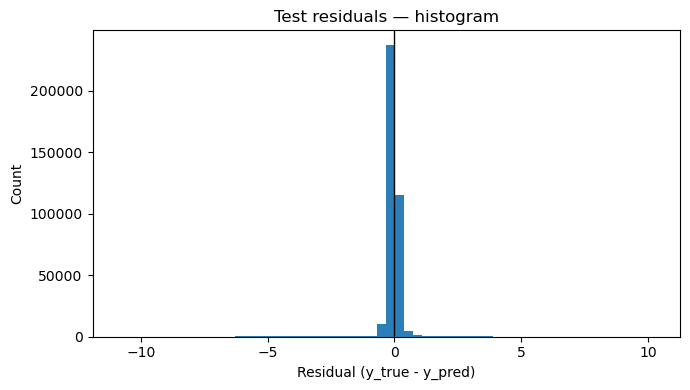

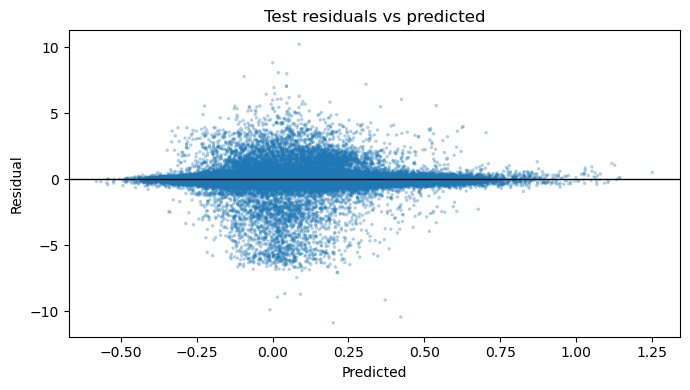

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# If starting fresh, load what you saved:
# out = pd.read_parquet("test_predictions.parquet")

# Make sure the columns are named consistently
preds = out.rename(columns={"residual_pred": "y_pred", target: "y_true"}).copy()
preds["valid_time"] = pd.to_datetime(preds["valid_time"])
preds["residual"] = preds["y_true"] - preds["y_pred"]

# --- A) Residual histogram ---
plt.figure(figsize=(7,4))
plt.hist(preds["residual"].dropna(), bins=60, alpha=0.95)
plt.axvline(0, color="k", lw=1)
plt.xlabel("Residual (y_true - y_pred)")
plt.ylabel("Count")
plt.title("Test residuals — histogram")
plt.tight_layout()
plt.show()

# --- B) Residuals vs Predicted (heteroscedasticity check) ---
plt.figure(figsize=(7,4))
plt.scatter(preds["y_pred"], preds["residual"], s=6, alpha=0.35, edgecolors="none")
plt.axhline(0, color="k", lw=1)
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.title("Test residuals vs predicted")
plt.tight_layout()
plt.show()


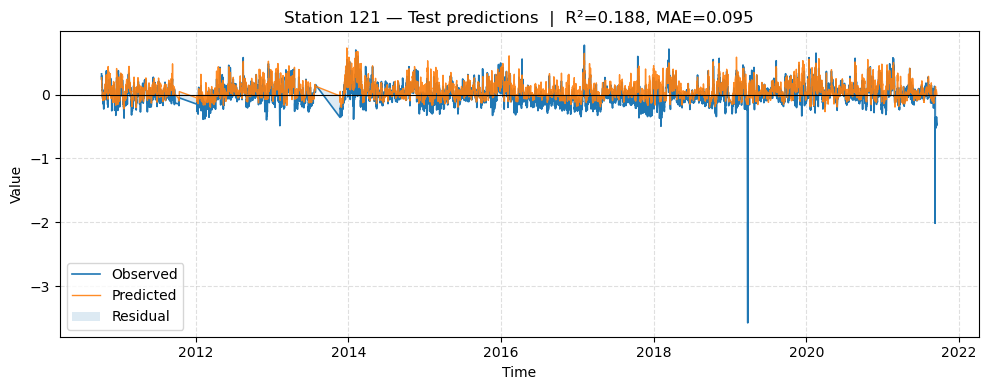

In [128]:
from sklearn.metrics import r2_score, mean_absolute_error

def plot_station_residuals(station_id):
    g = preds[preds["station"] == station_id].sort_values("valid_time")
    if g.empty:
        print(f"No test rows for station {station_id}")
        return
    r2  = r2_score(g["y_true"], g["y_pred"])
    mae = mean_absolute_error(g["y_true"], g["y_pred"])

    plt.figure(figsize=(10,4))
    plt.plot(g["valid_time"], g["y_true"], label="Observed", lw=1.2)
    plt.plot(g["valid_time"], g["y_pred"], label="Predicted", lw=1.0, alpha=0.9)
    plt.fill_between(g["valid_time"], g["y_pred"], g["y_true"], alpha=0.15, label="Residual")
    plt.axhline(0, color="k", lw=0.8)
    plt.title(f"Station {station_id} — Test predictions  |  R²={r2:.3f}, MAE={mae:.3f}")
    plt.xlabel("Time"); plt.ylabel("Value"); plt.grid(True, ls="--", alpha=0.4)
    plt.legend(); plt.tight_layout(); plt.show()

# Example:
plot_station_residuals(preds['station'].iloc[0])


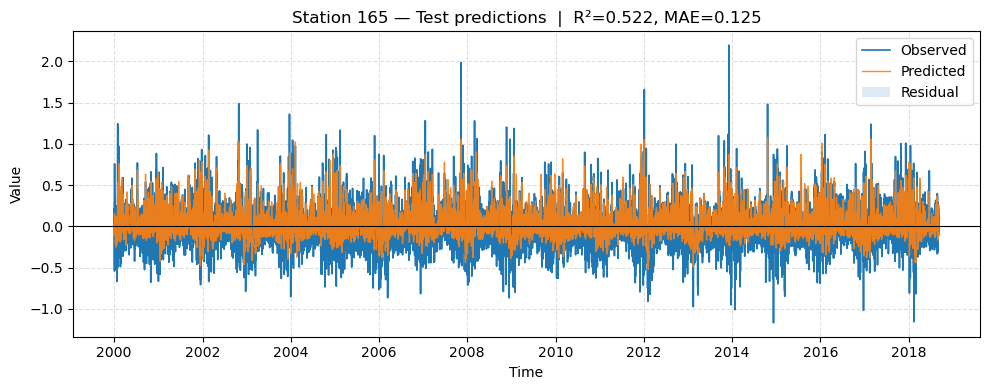

In [129]:
from sklearn.metrics import r2_score, mean_absolute_error

def plot_station_residuals(station_id):
    g = preds[preds["station"] == station_id].sort_values("valid_time")
    if g.empty:
        print(f"No test rows for station {station_id}")
        return
    r2  = r2_score(g["y_true"], g["y_pred"])
    mae = mean_absolute_error(g["y_true"], g["y_pred"])

    plt.figure(figsize=(10,4))
    plt.plot(g["valid_time"], g["y_true"], label="Observed", lw=1.2)
    plt.plot(g["valid_time"], g["y_pred"], label="Predicted", lw=1.0, alpha=0.9)
    plt.fill_between(g["valid_time"], g["y_pred"], g["y_true"], alpha=0.15, label="Residual")
    plt.axhline(0, color="k", lw=0.8)
    plt.title(f"Station {station_id} — Test predictions  |  R²={r2:.3f}, MAE={mae:.3f}")
    plt.xlabel("Time"); plt.ylabel("Value"); plt.grid(True, ls="--", alpha=0.4)
    plt.legend(); plt.tight_layout(); plt.show()

# Example:
plot_station_residuals(preds['station'].iloc[32])

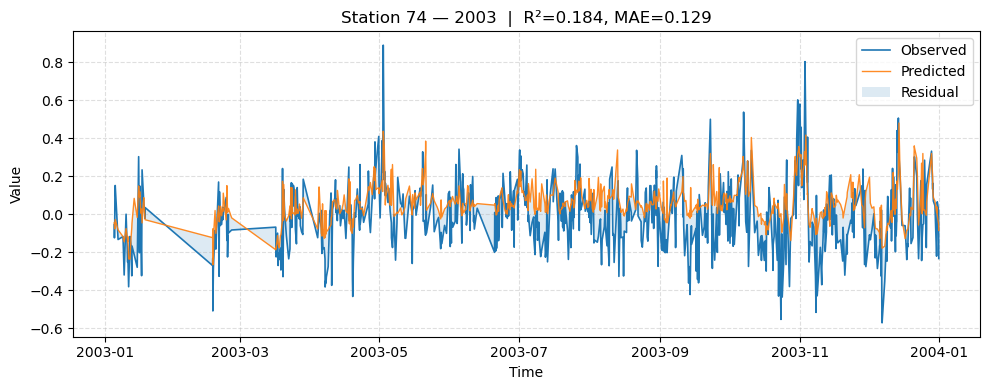

In [131]:
from sklearn.metrics import r2_score, mean_absolute_error

def plot_station_residuals(station_id, year=None):
    g = preds[preds["station"] == station_id].sort_values("valid_time").copy()
    if g.empty:
        print(f"No test rows for station {station_id}")
        return
    
    if year is not None:
        g = g[g["valid_time"].dt.year == year]
        if g.empty:
            print(f"No test rows for station {station_id} in year {year}")
            return
    
    r2  = r2_score(g["y_true"], g["y_pred"])
    mae = mean_absolute_error(g["y_true"], g["y_pred"])

    plt.figure(figsize=(10,4))
    plt.plot(g["valid_time"], g["y_true"], label="Observed", lw=1.2)
    plt.plot(g["valid_time"], g["y_pred"], label="Predicted", lw=1.0, alpha=0.9)
    plt.fill_between(g["valid_time"], g["y_pred"], g["y_true"], alpha=0.15, label="Residual")
    plt.title(f"Station {station_id} — {year if year else 'Full period'}  |  R²={r2:.3f}, MAE={mae:.3f}")
    plt.xlabel("Time"); plt.ylabel("Value")
    plt.grid(True, ls="--", alpha=0.4)
    plt.legend(); plt.tight_layout(); plt.show()

# Example: first station in 2017
plot_station_residuals(preds['station'].iloc[1], year=2003)


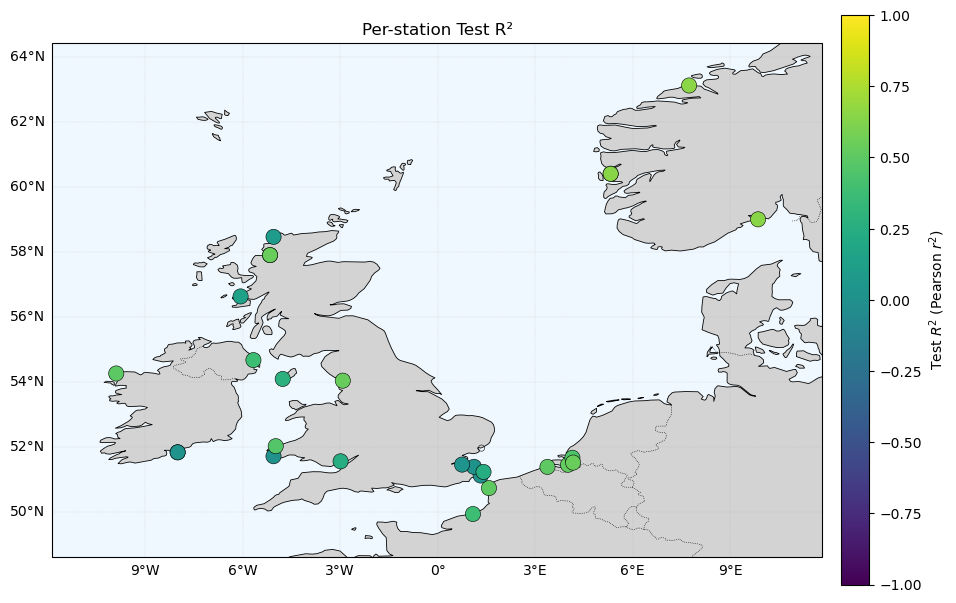

In [136]:
# pip install cartopy matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import Normalize

LAT, LON = "station_latitude", "station_longitude"

def to_minus180_180(lon):
    lon = np.asarray(lon, dtype=float)
    return ((lon + 180.0) % 360.0) - 180.0

def pearson_r(a, b):
    a = np.asarray(a, float); b = np.asarray(b, float)
    if len(a) < 2 or np.isclose(a.std(), 0) or np.isclose(b.std(), 0):
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

# ---------- 1) Gather per-row test predictions with coords ----------
te_idx = merged.index[m_test]
pred_df = merged.loc[te_idx, ['station', LAT, LON]].copy()
pred_df['y_true'] = np.asarray(y_test, dtype=float)
pred_df['y_pred'] = np.asarray(yhat_te, dtype=float)
pred_df['station'] = pred_df['station'].astype(str)

# ---------- 2) Per-station R2 (Pearson r^2) on the test set ----------
rows = []
for sid, g in pred_df.groupby('station', sort=True):
    r = pearson_r(g['y_true'], g['y_pred'])
    lat = g[LAT].dropna().iloc[0] if g[LAT].notna().any() else np.nan
    lon = g[LON].dropna().iloc[0] if g[LON].notna().any() else np.nan
    rows.append({
        'station': sid,
        LAT: lat,
        LON: lon,
        'n_test': len(g),
        'R': r,
        'R2': (r**2) if np.isfinite(r) else np.nan,
        'R4': (r**4) if np.isfinite(r) else np.nan,
    })

st_scores = pd.DataFrame(rows)
# normalize longitudes to [-180, 180] just in case
st_scores[LON] = to_minus180_180(st_scores[LON])

# ---------- 3) Plot R2 per station on a Cartopy map ----------
plot_df = st_scores.dropna(subset=[LAT, LON]).copy()

# Map extent with padding
lon_min, lon_max = float(plot_df[LON].min()), float(plot_df[LON].max())
lat_min, lat_max = float(plot_df[LAT].min()),  float(plot_df[LAT].max())
d_lon = (lon_max - lon_min) if lon_max > lon_min else 1.0
d_lat = (lat_max - lat_min) if lat_max > lat_min else 1.0
pad = 0.1
extent = [lon_min - pad*d_lon, lon_max + pad*d_lon,
          lat_min - pad*d_lat, lat_max + pad*d_lat]

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection=proj)
ax.set_extent(extent, crs=proj)

# Basemap
ax.add_feature(cfeature.LAND, facecolor="lightgray", zorder=0)
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue", zorder=0)
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.5)
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5, linestyle="--")
gl.right_labels = False; gl.top_labels = False

# Color by R2 (Pearson r^2 in [0,1])
norm = Normalize(vmin=-1.0, vmax=1.0)
sc = ax.scatter(
    plot_df[LON], plot_df[LAT],
    c=plot_df['R2'], cmap='viridis', norm=norm,
    s=np.clip(plot_df['n_test']*3, 20, 120),   # size ~ #test samples
    edgecolor='k', linewidth=0.4,
    transform=proj, zorder=5
)

cbar = plt.colorbar(sc, ax=ax, orientation='vertical', pad=0.02, shrink=0.85)
cbar.set_label(r'Test $R^2$ (Pearson $r^2$)')
plt.title("Per-station Test R²")
plt.tight_layout()
plt.show()



In [ ]:
# --- replace your Section 4–6 with this MLP version ---

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np
import pandas as pd

# 4) MLP model (with impute+scale)
mlp_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler(with_mean=True, with_std=True)),
    ("mlp",     MLPRegressor(
        hidden_layer_sizes=(256, 128, 64),  # try (256,128) or (512,256,128) if you want more capacity
        activation="relu",
        solver="adam",
        alpha=1e-4,              # L2 weight decay
        learning_rate_init=1e-3,
        batch_size=2048,         # tune depending on RAM
        max_iter=200,            # optimizer steps (epochs)
        early_stopping=True,     # uses 10% of TRAIN as internal validation
        n_iter_no_change=15,
        validation_fraction=0.1,
        shuffle=True,
        random_state=RANDOM_SEED,
        verbose=False,
    ))
])

mlp_pipe.fit(X_train, y_train)

# 5) Evaluate
def evaluate(name, X, y, m):
    pred = m.predict(X)
    r2 = r2_score(y, pred)
    mae = mean_absolute_error(y, pred)
    print(f"{name:>5} | R2: {r2:.4f} | MAE: {mae:.4f}")
    return pred

print("Performance (MLP):")
_ = evaluate("Train", X_train, y_train, mlp_pipe)
_ = evaluate(" Val ", X_val,   y_val,   mlp_pipe)
test_pred = evaluate("Test ", X_test,  y_test,  mlp_pipe)

# 6) Save test predictions (same as before)
out = df.loc[m_test, ["station", "valid_time", target]].copy()
out["residual_pred"] = test_pred
out.sort_values(["station", "valid_time"]).to_parquet("test_predictions.parquet", index=False)

print("Saved: test_predictions.parquet")

/Users/lb962/miniconda3/envs/ESL/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:698: UserWarning: Training interrupted by user.
  warnings.warn("Training interrupted by user.")


Performance (MLP):
